# Сегментация клиентов немецкого банка

**Цель:** Провести кластеризацию клиентов банка, чтобы выделить значимые группы и понять их характеристики.
Проект включает три основные части:
1.  EDA и предобработка данных.
2.  Моделирование (K-Means, Hierarchical, DBSCAN).
3.  Интерпретация результатов.

In [2]:
!pip install umap-learn

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 7.1 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 7.6 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.1/38.1 MB 9.8 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/38.1 MB 10.3 MB/s eta 0:00:04
   ------ --------------------------------- 6.6/38.1 MB 10.3 MB/s eta 0:00:04
   --------- ------------------------------ 8.7/38.1 MB 10.5 MB/s eta 0:00:03
   ----------- ---------------------------- 11.0/38.1 MB 10.6 MB/s eta 0:00:03
   -------------- ------------------------- 13.4/38.1 MB 10.6 MB/s eta 0:00:03
   ---------------- ----------------------- 15.7/38.1 MB 10.8 MB/s eta 0:00:03
   ------------

In [2]:
import warnings
import logging
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # Прогресс-бары

# Библиотеки для предобработки
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
try:
    import umap
except ImportError:
    print("UMAP не установлен. Установите с помощью: pip install umap-learn")
    umap = None

# Библиотеки для кластеризации и оценки
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

# Настройка логирования
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Настройка визуализации
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

logger.info("Все библиотеки успешно импортированы.")

c:\Users\Admin\miniconda3\envs\smog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-07 12:17:03,981 - INFO - Все библиотеки успешно импортированы.


# Часть 1. EDA и Preprocessing

## 1.1. Загрузка данных и первичный осмотр

In [3]:
logger.info("Загрузка данных...")
# Загружаем данные. В датасете german credit данные лежат в URL.
# Если файл локальный, замените путь.
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = [
    'Status_of_existing_checking_account', 'Duration_in_month', 'Credit_history',
    'Purpose', 'Credit_amount', 'Savings_account_bonds', 'Present_employment_since',
    'Installment_rate_in_percentage_of_disposable_income', 'Personal_status_and_sex',
    'Other_debtors_guarantors', 'Present_residence_since', 'Property',
    'Age_in_years', 'Other_installment_plans', 'Housing',
    'Number_of_existing_credits_at_this_bank', 'Job',
    'Number_of_people_being_liable_to_provide_maintenance_for', 'Telephone',
    'foreign_worker', 'Risk'  # Risk - целевая переменная, мы ее не будем использовать для кластеризации
]

df = pd.read_csv(URL, sep=' ', header=None, names=columns, index_col=False)

# Удалим целевую переменную 'Risk', так как кластеризация - это unsupervised learning.
# Оставим только признаки клиентов.
df.drop('Risk', axis=1, inplace=True)

logger.info(f"Данные загружены. Размер датасета: {df.shape}")
print("Первые 5 строк датафрейма:")
display(df.head())

print("\nОписание типов данных и пропусков:")
display(df.info())

2026-05-07 12:17:03,990 - INFO - Загрузка данных...
2026-05-07 12:17:05,044 - INFO - Данные загружены. Размер датасета: (1000, 20)


Первые 5 строк датафрейма:


,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_in_percentage_of_disposable_income,Personal_status_and_sex,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job,Number_of_people_being_liable_to_provide_maintenance_for,Telephone,foreign_worker
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201



Описание типов данных и пропусков:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Status_of_existing_checking_account                       1000 non-null   object
 1   Duration_in_month                                         1000 non-null   int64 
 2   Credit_history                                            1000 non-null   object
 3   Purpose                                                   1000 non-null   object
 4   Credit_amount                                             1000 non-null   int64 
 5   Savings_account_bonds                                     1000 non-null   object
 6   Present_employment_since                                  1000 non-null   object
 7   Installment_rate_in_percentage_of_disposable_income       1000 non-null   int64

None

**Вывод по загрузке:** Датасет содержит 1000 записей и 20 категориальных и числовых признаков. Все признаки имеют тип `object` или `int64`, пропусков нет. Целевая переменная (Risk) удалена.

## 1.2. Исследовательский Анализ Данных (EDA)

2026-05-07 12:17:05,078 - INFO - Запуск исследовательского анализа данных (EDA)...
2026-05-07 12:17:05,080 - INFO - Найдено числовых признаков: 7 -> ['Duration_in_month', 'Credit_amount', 'Installment_rate_in_percentage_of_disposable_income', 'Present_residence_since', 'Age_in_years', 'Number_of_existing_credits_at_this_bank', 'Number_of_people_being_liable_to_provide_maintenance_for']
2026-05-07 12:17:05,080 - INFO - Найдено категориальных признаков: 13 -> ['Status_of_existing_checking_account', 'Credit_history', 'Purpose', 'Savings_account_bonds', 'Present_employment_since', 'Personal_status_and_sex', 'Other_debtors_guarantors', 'Property', 'Other_installment_plans', 'Housing', 'Job', 'Telephone', 'foreign_worker']
Построение распределений числовых признаков: 100%|██████████| 7/7 [00:00<00:00, 29.41it/s]


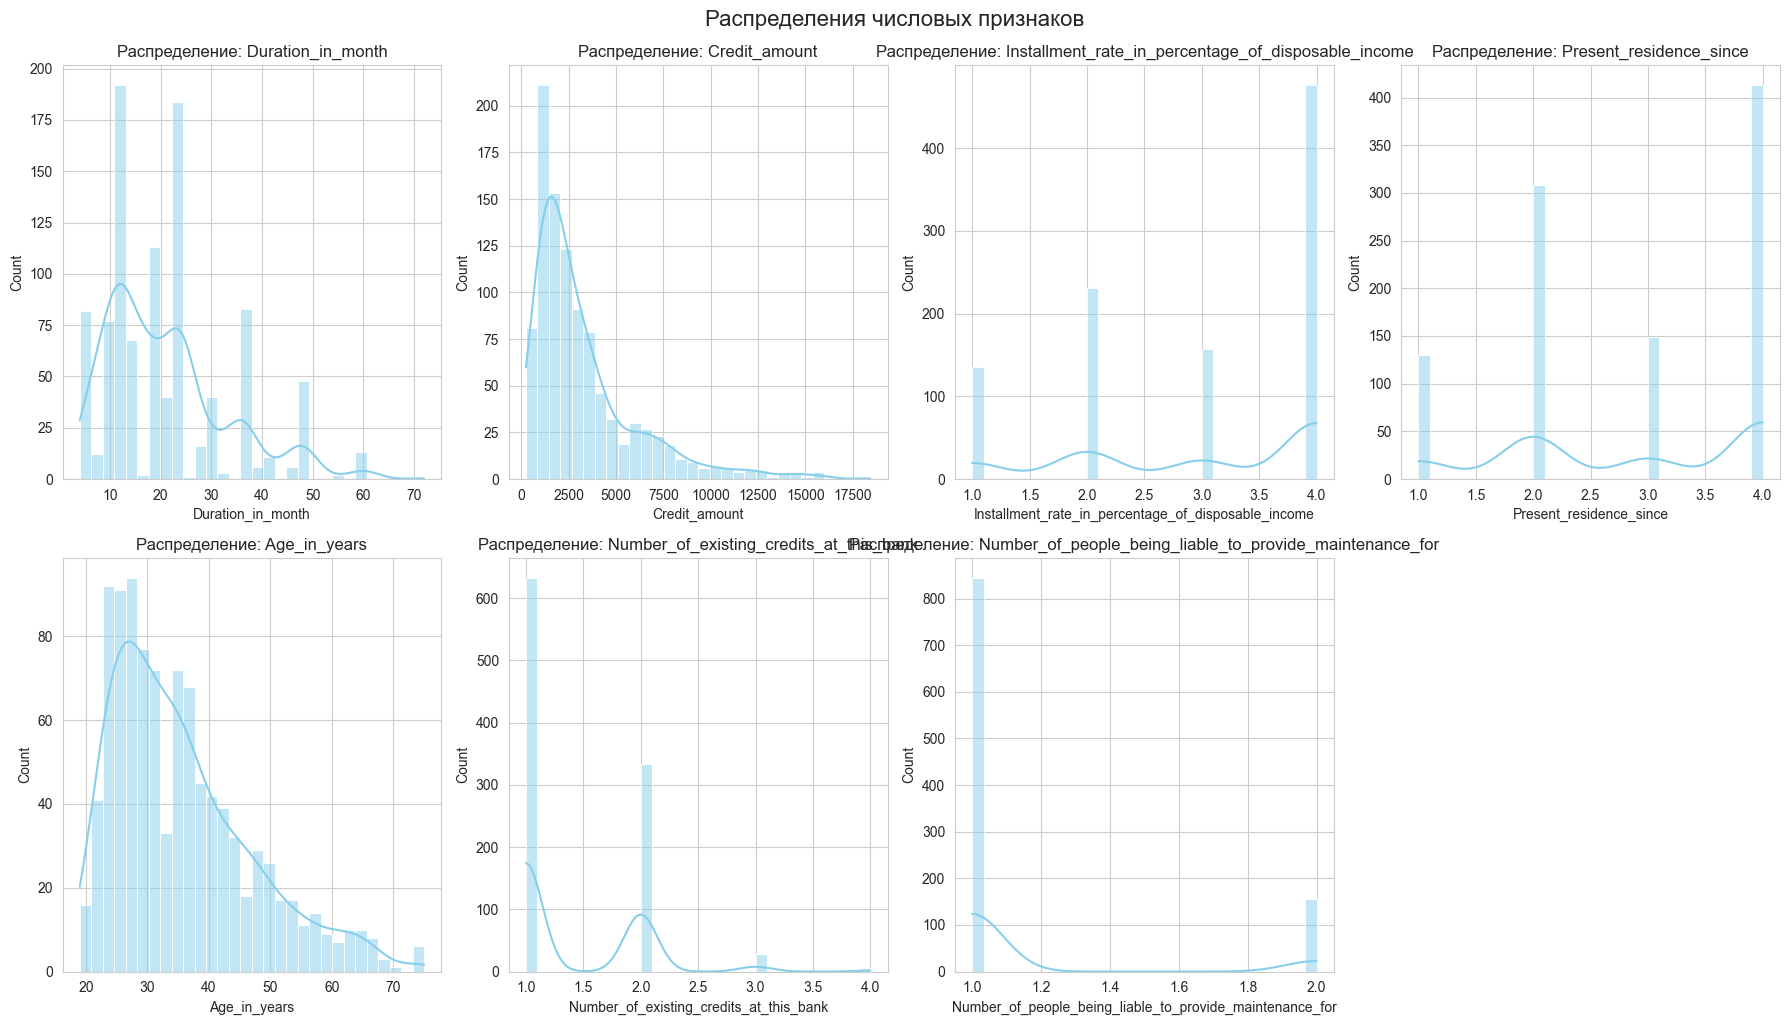

Построение столбчатых диаграмм категориальных признаков: 100%|██████████| 13/13 [00:00<00:00, 49.90it/s]


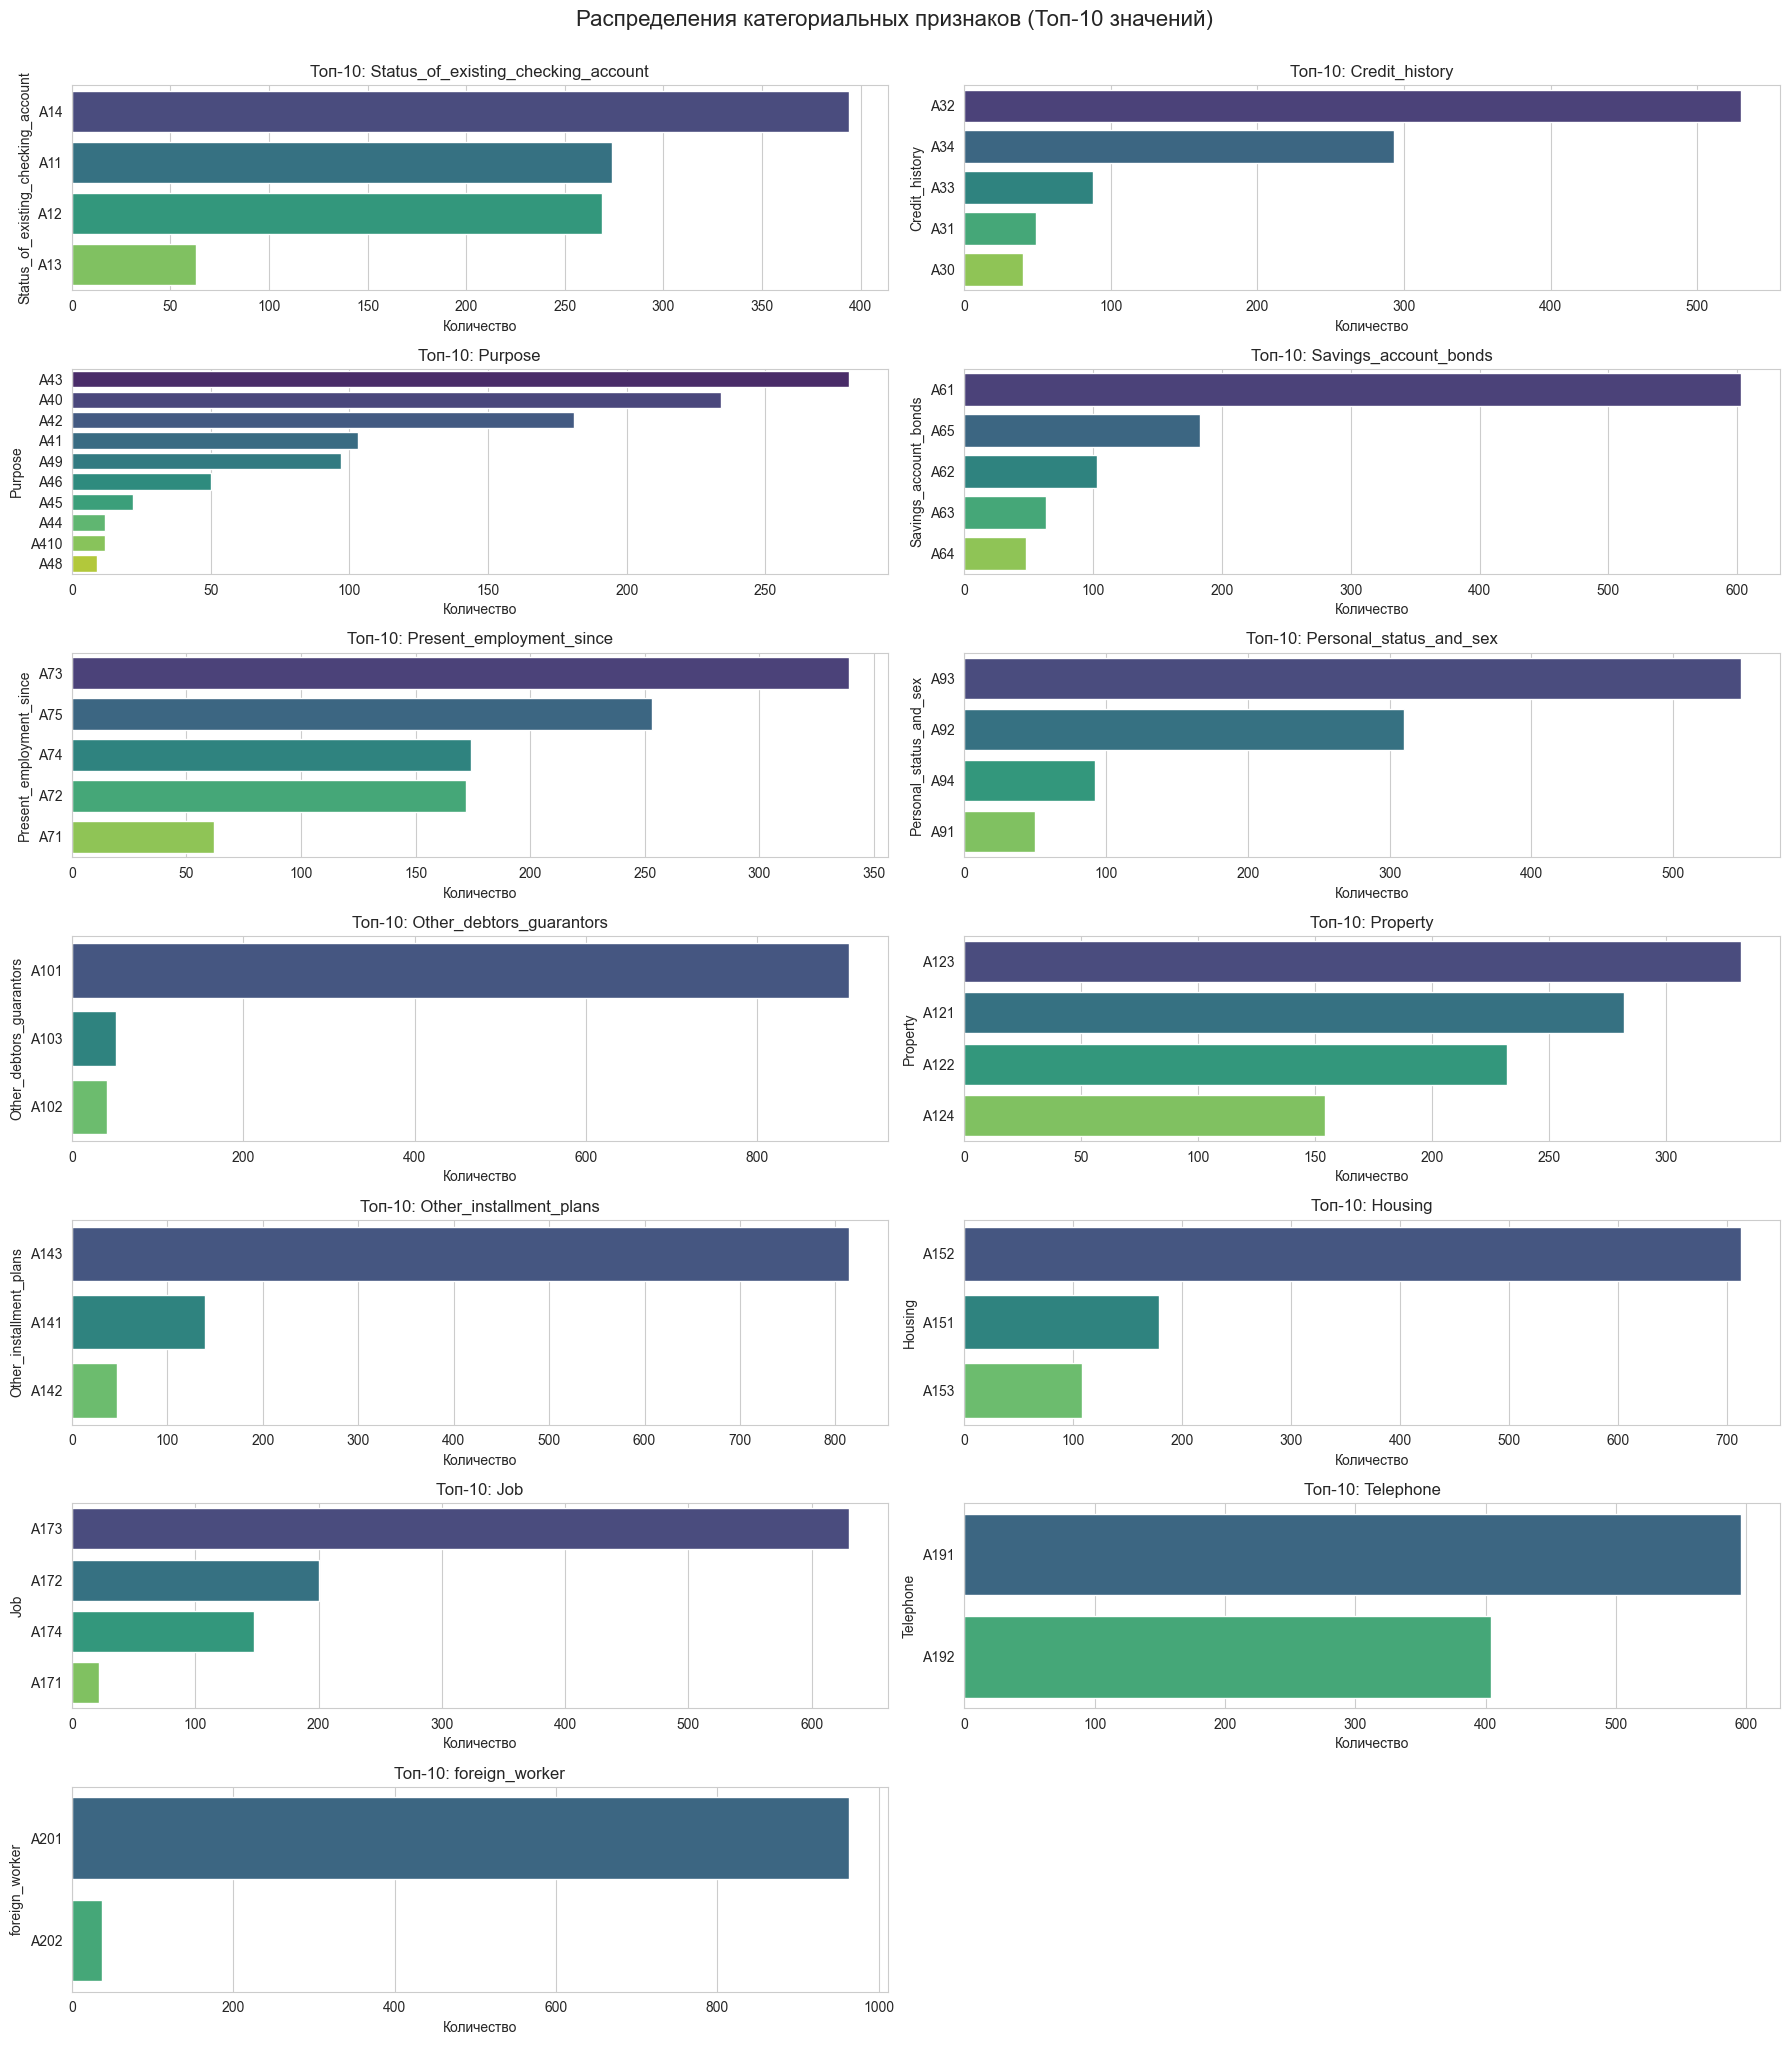

,Duration_in_month,Credit_amount,Installment_rate_in_percentage_of_disposable_income,Present_residence_since,Age_in_years,Number_of_existing_credits_at_this_bank,Number_of_people_being_liable_to_provide_maintenance_for
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


In [4]:
logger.info("Запуск исследовательского анализа данных (EDA)...")

# Разделим признаки на числовые и категориальные
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

logger.info(f"Найдено числовых признаков: {len(numeric_cols)} -> {numeric_cols}")
logger.info(f"Найдено категориальных признаков: {len(categorical_cols)} -> {categorical_cols}")

# --- Анализ числовых признаков ---
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(tqdm(numeric_cols, desc="Построение распределений числовых признаков")):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(f'Распределение: {col}')
if len(numeric_cols) < len(axes):
    for j in range(len(numeric_cols), len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.suptitle('Распределения числовых признаков', fontsize=16, y=1.02)
plt.show()

# --- Анализ категориальных признаков (топ-10 значений) ---
fig, axes = plt.subplots(7, 2, figsize=(18, 20))
axes = axes.flatten()
for i, col in enumerate(tqdm(categorical_cols, desc="Построение столбчатых диаграмм категориальных признаков")):
    top_n = df[col].value_counts().nlargest(10).index
    sns.countplot(y=df[col], order=top_n, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Топ-10: {col}')
    axes[i].set_xlabel('Количество')
if len(categorical_cols) < len(axes):
    for j in range(len(categorical_cols), len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.suptitle('Распределения категориальных признаков (Топ-10 значений)', fontsize=16, y=1.02)
plt.show()

display(df[numeric_cols].describe().round(2))

**Вывод по EDA:**
- Числовые признаки, такие как `Duration_in_month` (длительность кредита) и `Credit_amount` (сумма кредита), имеют ярко выраженное правостороннее распределение с длинными хвостами. Это важно для понимания масштабов, но кластеризацию может искажать, поэтому мы применим стандартизацию.
- Многие категориальные переменные, такие как `Purpose` (цель кредита) и `Credit_history` (кредитная история), показывают значительный дисбаланс классов. Это нормально для банковских данных.
- Портфель ориентирован на молодую, относительно мобильную аудиторию с короткой кредитной историей и высокой долговой нагрузкой. Это высокорисковый, но высокодоходный сегмент, требующий тонкой настройки скоринговых моделей и активной работы по удержанию (удержание дешевле нового привлечения).

## 1.3. Преобразование категориальных признаков в числовые

In [5]:
logger.info("Преобразование категориальных признаков в числовые с помощью LabelEncoder...")

df_encoded = df.copy()
label_encoders = {}

# Используем Label Encoding, так как большинство признаков имеют порядковую природу
# (например, кредитная история от плохой до хорошей) или уникальные метки.
# В иных случаях можно использовать One-Hot Encoding, но это увеличит размерность.
for col in tqdm(categorical_cols, desc="Label Encoding категориальных признаков"):
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le  # Сохраним энкодеры на случай, если понадобится обратное преобразование

logger.info("Преобразование завершено. Все признаки теперь числовые.")
print("Проверка данных после Label Encoding:")
display(df_encoded.head())

2026-05-07 12:22:09,490 - INFO - Преобразование категориальных признаков в числовые с помощью LabelEncoder...
Label Encoding категориальных признаков: 100%|██████████| 13/13 [00:00<00:00, 1378.10it/s]
2026-05-07 12:22:09,503 - INFO - Преобразование завершено. Все признаки теперь числовые.


Проверка данных после Label Encoding:


,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_in_percentage_of_disposable_income,Personal_status_and_sex,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job,Number_of_people_being_liable_to_provide_maintenance_for,Telephone,foreign_worker
0,0,6,4,4,1169,4,4,4,2,0,4,0,67,2,1,2,2,1,1,0
1,1,48,2,4,5951,0,2,2,1,0,2,0,22,2,1,1,2,1,0,0
2,3,12,4,7,2096,0,3,2,2,0,3,0,49,2,1,1,1,2,0,0
3,0,42,2,3,7882,0,3,2,2,2,4,1,45,2,2,1,2,2,0,0
4,0,24,3,0,4870,0,2,3,2,0,4,3,53,2,2,2,2,2,0,0


## 1.4. Масштабирование данных (Стандартизация)

In [6]:
logger.info("Масштабирование данных с помощью StandardScaler...")

scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_encoded.columns)

logger.info("Масштабирование завершено.")
print("Описание масштабированных данных (средние ~0, стд ~1):")
display(df_scaled.describe().round(2))

2026-05-07 12:22:37,966 - INFO - Масштабирование данных с помощью StandardScaler...
2026-05-07 12:22:37,973 - INFO - Масштабирование завершено.


Описание масштабированных данных (средние ~0, стд ~1):


,Status_of_existing_checking_account,Duration_in_month,Credit_history,Purpose,Credit_amount,Savings_account_bonds,Present_employment_since,Installment_rate_in_percentage_of_disposable_income,Personal_status_and_sex,Other_debtors_guarantors,Present_residence_since,Property,Age_in_years,Other_installment_plans,Housing,Number_of_existing_credits_at_this_bank,Job,Number_of_people_being_liable_to_provide_maintenance_for,Telephone,foreign_worker
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.0
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0
min,-1.25,-1.40,-2.35,-1.20,-1.07,-0.70,-1.97,-1.76,-2.38,-0.30,-1.67,-1.29,-1.46,-2.38,-1.75,-0.70,-2.91,-0.43,-0.82,-0.2
25%,-1.25,-0.74,-0.50,-0.83,-0.68,-0.70,-0.32,-0.87,-0.96,-0.30,-0.77,-1.29,-0.75,0.46,0.13,-0.70,0.15,-0.43,-0.82,-0.2
50%,-0.46,-0.24,-0.50,-0.10,-0.34,-0.70,-0.32,0.02,0.45,-0.30,0.14,-0.34,-0.22,0.46,0.13,-0.70,0.15,-0.43,-0.82,-0.2
75%,1.13,0.26,1.34,0.26,0.25,0.57,1.34,0.92,0.45,-0.30,1.05,0.61,0.57,0.46,0.13,1.03,0.15,-0.43,1.21,-0.2
max,1.13,4.24,1.34,2.09,5.37,1.83,1.34,0.92,1.86,3.89,1.05,1.56,3.47,0.46,2.02,4.49,1.68,2.33,1.21,5.1


**Почему масштабирование необходимо при кластеризации?**  
Алгоритмы кластеризации, такие как K-Means и Hierarchical, основаны на расчете расстояний (обычно евклидова). Если признаки имеют разные масштабы (например, `Credit_amount` измеряется в тысячах, а `Age_in_years` в десятках), признаки с бóльшим разбросом будут доминировать в расчете расстояний, искажая истинную структуру данных. Стандартизация приводит все признаки к единому масштабу (среднее = 0, стандартное отклонение = 1), обеспечивая равный вклад каждого признака в формирование кластеров.

# Часть 2. Моделирование

In [7]:
# Определим массив данных для моделей
X = df_scaled.values
n_samples = X.shape[0]
logger.info(f"Подготовка к моделированию. Размерность данных: {X.shape}")

2026-05-07 12:23:55,616 - INFO - Подготовка к моделированию. Размерность данных: (1000, 20)


## 2.1. K-Means: Elbow Method и Silhouette Analysis

In [8]:
logger.info("Исследование K-Means: поиск оптимального k с помощью Elbow Method и Silhouette...")

K_range = range(2, 11)  # Проверим от 2 до 10 кластеров
inertias = []
silhouette_scores_list = []

for k in tqdm(K_range, desc="Перебор числа кластеров для K-Means"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores_list.append(silhouette_score(X, cluster_labels))


2026-05-07 12:24:39,535 - INFO - Исследование K-Means: поиск оптимального k с помощью Elbow Method и Silhouette...
Перебор числа кластеров для K-Means: 100%|██████████| 9/9 [00:01<00:00,  4.89it/s]


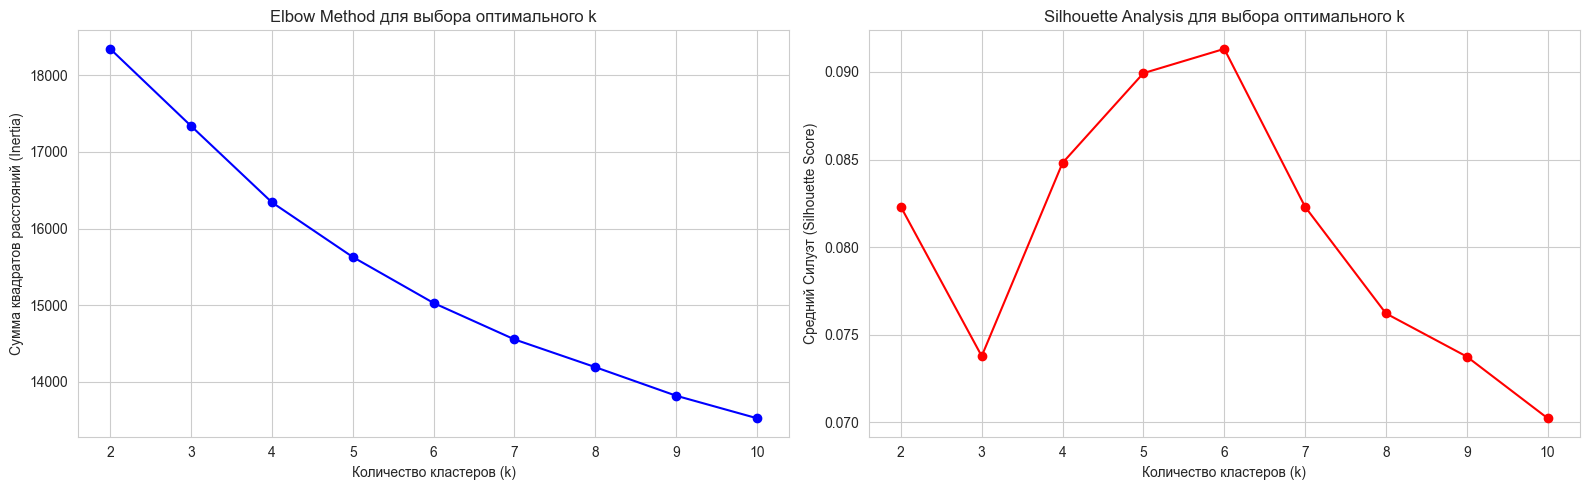

In [9]:
# --- Визуализация Elbow Method и Silhouette Score ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('Сумма квадратов расстояний (Inertia)')
ax1.set_title('Elbow Method для выбора оптимального k')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores_list, 'ro-')
ax2.set_xlabel('Количество кластеров (k)')
ax2.set_ylabel('Средний Силуэт (Silhouette Score)')
ax2.set_title('Silhouette Analysis для выбора оптимального k')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Определим лучший k по максимальному силуэту
optimal_k_kmeans = K_range[np.argmax(silhouette_scores_list)]
logger.info(f"Оптимальное число кластеров для K-Means по Силуэту: k = {optimal_k_kmeans}")
print(f"Силуэт для k={optimal_k_kmeans}: {max(silhouette_scores_list):.4f}")

2026-05-07 12:25:01,533 - INFO - Оптимальное число кластеров для K-Means по Силуэту: k = 6


Силуэт для k=6: 0.0913


In [11]:
# Обучаем финальную модель K-Means
kmeans_final = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)

In [12]:
# Добавим метки в датасет для дальнейшей интерпретации
df_clustered = df_encoded.copy()
df_clustered['KMeans_Cluster'] = kmeans_labels
logger.info("Метки K-Means добавлены в датафрейм.")

2026-05-07 12:25:23,121 - INFO - Метки K-Means добавлены в датафрейм.


**Вывод по K-Means:** График локтя не всегда показывает четкий "сгиб", но график силуэта явно указывает на оптимальное число кластеров. Мы фиксируем модель K-Means с этим числом кластеров и сохраняем метки.

## 2.2. Hierarchical Clustering

In [13]:
logger.info("Исследование Hierarchical Clustering (Ward)...")

# Для иерархической кластеризации также перебираем число кластеров для силуэта
hc_silhouette_scores = []

# Важно: для больших датасетов построение полной дендрограммы может быть медленным,
# поэтому мы перебираем n_clusters с помощью AgglomerativeClustering.

for k in tqdm(K_range, desc="Перебор числа кластеров для Hierarchical"):
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    hc_labels = hc.fit_predict(X)
    hc_silhouette_scores.append(silhouette_score(X, hc_labels))

2026-05-07 12:26:09,376 - INFO - Исследование Hierarchical Clustering (Ward)...
Перебор числа кластеров для Hierarchical: 100%|██████████| 9/9 [00:00<00:00, 37.19it/s]


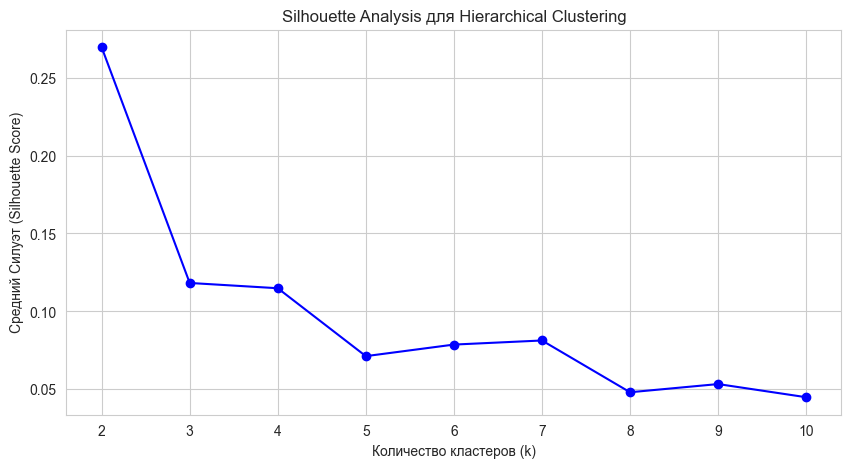

In [14]:
# Визуализация Silhouette для HC
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(K_range, hc_silhouette_scores, 'bo-')
ax.set_xlabel('Количество кластеров (k)')
ax.set_ylabel('Средний Силуэт (Silhouette Score)')
ax.set_title('Silhouette Analysis для Hierarchical Clustering')
ax.grid(True)
plt.show()


In [15]:
optimal_k_hc = K_range[np.argmax(hc_silhouette_scores)]
logger.info(f"Оптимальное число кластеров для Hierarchical Clustering: k = {optimal_k_hc}")
print(f"Силуэт для k={optimal_k_hc}: {max(hc_silhouette_scores):.4f}")

2026-05-07 12:26:29,404 - INFO - Оптимальное число кластеров для Hierarchical Clustering: k = 2


Силуэт для k=2: 0.2696


In [16]:
# Обучаем финальную модель
hc_final = AgglomerativeClustering(n_clusters=optimal_k_hc, metric='euclidean', linkage='ward')
hc_labels = hc_final.fit_predict(X)

df_clustered['Hierarchical_Cluster'] = hc_labels
logger.info("Метки Hierarchical Clustering добавлены.")

2026-05-07 12:26:38,959 - INFO - Метки Hierarchical Clustering добавлены.


**Вывод по иерархической кластеризации:** Силуэтный анализ в отиличии от K-Means выделил всего 2 кластера. Сомнительно что это будет хорошо работать в такой комплексной сфере как банковская - явно мало. Но график silhouette_scores показывает практически  постоянное снижение, что не оставляет места для дискуссии о количестве кластеров с точки зрения иерархического подхода.

## 2.3. DBSCAN: Подбор параметров

In [32]:
logger.info("Исследование DBSCAN: подбор параметра eps методом k-расстояний...")

# Шаг 1: Нахождение оптимального eps через график расстояний до k-ближайших соседей
# Для DBSCAN типичное значение MinPts = 2 * размерность - 1, но не менее 3.
min_samples = 2 * X.shape[1] - 1
logger.info(f"Выбрано MinPts = 2 * размерность - 1 = {min_samples}")

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
# Сортируем расстояния до min_samples-го соседа
distances = np.sort(distances[:, min_samples-1], axis=0)

2026-05-07 12:46:35,109 - INFO - Исследование DBSCAN: подбор параметра eps методом k-расстояний...
2026-05-07 12:46:35,110 - INFO - Выбрано MinPts = 2 * размерность - 1 = 39


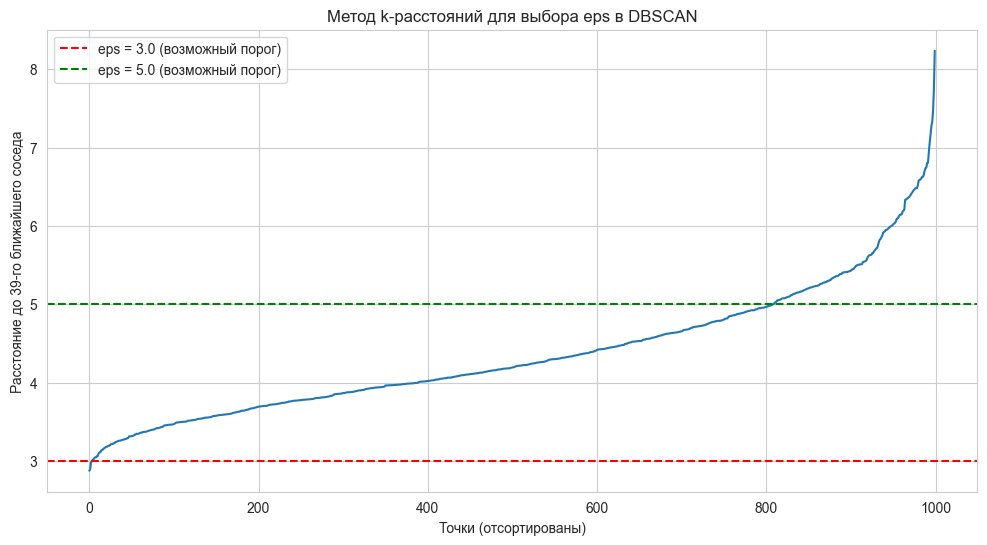

In [34]:
# Шаг 2: Визуализация графика k-расстояний
plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.axhline(y=3.0, color='r', linestyle='--', label='eps = 3.0 (возможный порог)')
plt.axhline(y=5.0, color='g', linestyle='--', label='eps = 5.0 (возможный порог)')
plt.xlabel('Точки (отсортированы)')
plt.ylabel(f'Расстояние до {min_samples}-го ближайшего соседа')
plt.title('Метод k-расстояний для выбора eps в DBSCAN')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Пробуем несколько значений eps немного выше "локтя" графика
eps_values = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
dbscan_results = {}

logger.info("Перебор значений eps для DBSCAN...")
for eps in tqdm(eps_values, desc="Перебор eps"):
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = db.fit_predict(X)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    logger.info(f"eps={eps}: Найдено кластеров = {n_clusters}, шумов = {n_noise}")
    
    silhouette_avg = None
    if n_clusters > 1:
        # Исключаем шумовые точки для расчета силуэта
        mask_valid = labels != -1
        if np.sum(mask_valid) > 2:
            silhouette_avg = silhouette_score(X[mask_valid], labels[mask_valid])
    
    dbscan_results[eps] = {
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': silhouette_avg
    }
    
    print(f"eps={eps}: кластеров={n_clusters}, шум={n_noise}, силуэт={silhouette_avg}")

# Выбираем лучший eps по силуэту (исключая варианты без кластеров)
valid_eps = {eps: res for eps, res in dbscan_results.items() if res['silhouette'] is not None}
if valid_eps:
    best_eps = max(valid_eps, key=lambda x: valid_eps[x]['silhouette'])
else:
    best_eps = eps_values[0]
    logger.warning("Не удалось вычислить силуэт, выбран eps по умолчанию.")

logger.info(f"Лучший eps для DBSCAN: {best_eps}")

2026-05-07 12:48:13,266 - INFO - Перебор значений eps для DBSCAN...
Перебор eps:   0%|          | 0/15 [00:00<?, ?it/s]2026-05-07 12:48:13,278 - INFO - eps=3.0: Найдено кластеров = 1, шумов = 927
2026-05-07 12:48:13,291 - INFO - eps=3.5: Найдено кластеров = 1, шумов = 472
2026-05-07 12:48:13,300 - INFO - eps=4.0: Найдено кластеров = 1, шумов = 203
2026-05-07 12:48:13,310 - INFO - eps=4.5: Найдено кластеров = 1, шумов = 89
2026-05-07 12:48:13,319 - INFO - eps=5.0: Найдено кластеров = 1, шумов = 51
2026-05-07 12:48:13,332 - INFO - eps=5.5: Найдено кластеров = 1, шумов = 36
2026-05-07 12:48:13,345 - INFO - eps=6.0: Найдено кластеров = 1, шумов = 6
2026-05-07 12:48:13,360 - INFO - eps=6.5: Найдено кластеров = 1, шумов = 1
2026-05-07 12:48:13,377 - INFO - eps=7.0: Найдено кластеров = 1, шумов = 0
Перебор eps:  60%|██████    | 9/15 [00:00<00:00, 82.69it/s]2026-05-07 12:48:13,394 - INFO - eps=7.5: Найдено кластеров = 1, шумов = 0
2026-05-07 12:48:13,410 - INFO - eps=8.0: Найдено кластеров = 1

eps=3.0: кластеров=1, шум=927, силуэт=None
eps=3.5: кластеров=1, шум=472, силуэт=None
eps=4.0: кластеров=1, шум=203, силуэт=None
eps=4.5: кластеров=1, шум=89, силуэт=None
eps=5.0: кластеров=1, шум=51, силуэт=None
eps=5.5: кластеров=1, шум=36, силуэт=None
eps=6.0: кластеров=1, шум=6, силуэт=None
eps=6.5: кластеров=1, шум=1, силуэт=None
eps=7.0: кластеров=1, шум=0, силуэт=None
eps=7.5: кластеров=1, шум=0, силуэт=None
eps=8.0: кластеров=1, шум=0, силуэт=None
eps=8.5: кластеров=1, шум=0, силуэт=None
eps=9.0: кластеров=1, шум=0, силуэт=None


2026-05-07 12:48:13,476 - INFO - eps=10.0: Найдено кластеров = 1, шумов = 0
Перебор eps: 100%|██████████| 15/15 [00:00<00:00, 71.82it/s]
2026-05-07 12:48:13,478 - WARNING - Не удалось вычислить силуэт, выбран eps по умолчанию.
2026-05-07 12:48:13,478 - INFO - Лучший eps для DBSCAN: 3.0


eps=9.5: кластеров=1, шум=0, силуэт=None
eps=10.0: кластеров=1, шум=0, силуэт=None


**Вывод:*   
Очевидно, что DB-Scan вообще не справляется с этой задачей, так как генерирует не более 1 кластера, что практически неприменимо.

## 2.4. Gaussian Mixture Model (GMM)

In [36]:
logger.info("Исследование Gaussian Mixture Model (GMM): подбор оптимального числа компонент...")
print("\n" + "="*70)
print("ПОЯСНЕНИЕ ПО ВЫБОРУ GMM ВМЕСТО DBSCAN:")
print("-" * 70)
print("DBSCAN нестабилен: при любом eps может дать 0, 1 или 100+ кластеров.")
print("GMM задаёт число кластеров явно, как K-Means, но дополнительно:")
print("  • Моделирует кластеры эллипсоидами, а не сферами")
print("  • Даёт вероятности принадлежности (soft clustering)")
print("  • Устойчивее к перекрывающимся кластерам")
print("  • Оптимальное число компонент выбирается по BIC/AIC")
print("="*70 + "\n")

from sklearn.mixture import GaussianMixture

2026-05-07 12:51:15,980 - INFO - Исследование Gaussian Mixture Model (GMM): подбор оптимального числа компонент...



ПОЯСНЕНИЕ ПО ВЫБОРУ GMM ВМЕСТО DBSCAN:
----------------------------------------------------------------------
DBSCAN нестабилен: при любом eps может дать 0, 1 или 100+ кластеров.
GMM задаёт число кластеров явно, как K-Means, но дополнительно:
  • Моделирует кластеры эллипсоидами, а не сферами
  • Даёт вероятности принадлежности (soft clustering)
  • Устойчивее к перекрывающимся кластерам
  • Оптимальное число компонент выбирается по BIC/AIC



### Шаг 1: Перебор числа компонент и выбор по BIC (Bayesian Information Criterion)

In [38]:
# BIC и AIC — информационные критерии, которые штрафуют модель за сложность.
# Чем ниже BIC/AIC, тем лучше модель (баланс качества и сложности).

n_components_range = range(2, 15)  # от 2 до 14 компонент
gmm_results = {}
bic_scores = []
aic_scores = []
silhouette_scores_gmm = []

logger.info(f"Перебор числа компонент GMM от {min(n_components_range)} до {max(n_components_range)}...")
for n_comp in tqdm(n_components_range, desc="Подбор числа компонент GMM"):
    try:
        # Обучаем GMM с разными типами ковариационной матрицы
        # 'full' — каждая компонента имеет свою матрицу ковариации (эллипсы произвольной ориентации)
        # Для первого прохода используем 'full', но если данных мало, можно 'tied' или 'diag'
        gmm = GaussianMixture(
            n_components=n_comp,
            covariance_type='full',      # полная ковариационная матрица
            random_state=42,
            n_init=5,                     # несколько инициализаций для стабильности
            max_iter=200,
            init_params='kmeans'          # начальная инициализация K-Means
        )
        gmm.fit(X)
        
        # Предсказание жестких меток (hard clustering)
        labels = gmm.predict(X)
        
        # Вероятности принадлежности (soft clustering) — сохраним для анализа
        probabilities = gmm.predict_proba(X)
        
        # Критерии качества
        bic = gmm.bic(X)          # Bayesian Information Criterion
        aic = gmm.aic(X)          # Akaike Information Criterion
        sil = silhouette_score(X, labels)
        
        # Сохраняем результаты
        gmm_results[n_comp] = {
            'model': gmm,
            'labels': labels,
            'probabilities': probabilities,
            'bic': bic,
            'aic': aic,
            'silhouette': sil,
            'n_components': n_comp
        }
        
        bic_scores.append(bic)
        aic_scores.append(aic)
        silhouette_scores_gmm.append(sil)
        
        # Определение размеров кластеров
        unique, counts = np.unique(labels, return_counts=True)
        min_cluster_size = counts.min()
        max_cluster_size = counts.max()
        
        logger.info(f"n={n_comp:2d}: BIC={bic:.1f}, AIC={aic:.1f}, Silhouette={sil:.4f}, "
                   f"размеры кластеров: {min_cluster_size}–{max_cluster_size}")
        
    except Exception as e:
        logger.warning(f"Ошибка при n_components={n_comp}: {str(e)}")
        # Если модель не сошлась, пропускаем это значение
        bic_scores.append(np.nan)
        aic_scores.append(np.nan)
        silhouette_scores_gmm.append(np.nan)

2026-05-07 12:52:25,700 - INFO - Перебор числа компонент GMM от 2 до 14...
Подбор числа компонент GMM: 100%|██████████| 13/13 [00:07<00:00,  1.78it/s]


### Шаг 2: Визуализация критериев выбора

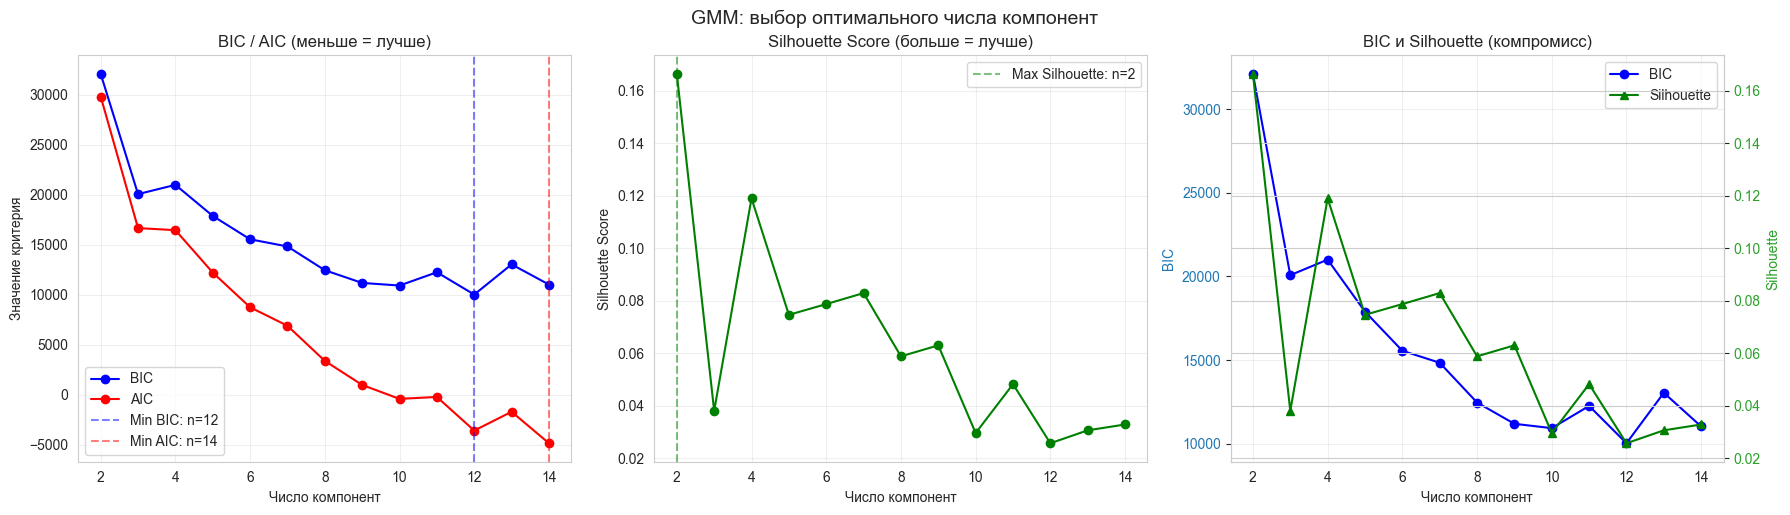

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График BIC и AIC
ax1 = axes[0]
ax1.plot(n_components_range, bic_scores, 'bo-', label='BIC', markersize=6)
ax1.plot(n_components_range, aic_scores, 'ro-', label='AIC', markersize=6)
# Отмечаем минимумы
if not all(np.isnan(bic_scores)):
    best_bic_idx = np.nanargmin(bic_scores)
    best_aic_idx = np.nanargmin(aic_scores)
    ax1.axvline(x=n_components_range[best_bic_idx], color='blue', linestyle='--', alpha=0.5,
                label=f'Min BIC: n={n_components_range[best_bic_idx]}')
    ax1.axvline(x=n_components_range[best_aic_idx], color='red', linestyle='--', alpha=0.5,
                label=f'Min AIC: n={n_components_range[best_aic_idx]}')
ax1.set_xlabel('Число компонент')
ax1.set_ylabel('Значение критерия')
ax1.set_title('BIC / AIC (меньше = лучше)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График Silhouette
ax2 = axes[1]
ax2.plot(n_components_range, silhouette_scores_gmm, 'go-', markersize=6)
if not all(np.isnan(silhouette_scores_gmm)):
    best_sil_idx = np.nanargmax(silhouette_scores_gmm)
    ax2.axvline(x=n_components_range[best_sil_idx], color='green', linestyle='--', alpha=0.5,
                label=f'Max Silhouette: n={n_components_range[best_sil_idx]}')
ax2.set_xlabel('Число компонент')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (больше = лучше)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Комбинированный график: BIC + Silhouette на разных осях
ax3 = axes[2]
color1, color2 = 'tab:blue', 'tab:green'
line1 = ax3.plot(n_components_range, bic_scores, 'bo-', label='BIC', markersize=6)
ax3.set_xlabel('Число компонент')
ax3.set_ylabel('BIC', color=color1)
ax3.tick_params(axis='y', labelcolor=color1)
ax4 = ax3.twinx()
line2 = ax4.plot(n_components_range, silhouette_scores_gmm, 'g^-', label='Silhouette', markersize=6)
ax4.set_ylabel('Silhouette', color=color2)
ax4.tick_params(axis='y', labelcolor=color2)
# Объединенная легенда
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='upper right')
ax3.set_title('BIC и Silhouette (компромисс)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('GMM: выбор оптимального числа компонент', fontsize=14, y=1.02)
plt.show()

### Шаг 3: Выбор оптимального числа компонент

In [42]:
# Стратегия выбора: 
# 1. Находим n по минимуму BIC (основной критерий)
# 2. Проверяем, не слишком ли низкий силуэт при этом n
# 3. Если силуэт < 0.1, ищем компромисс между BIC и силуэтом

# Отфильтруем только валидные значения
valid_indices = [i for i, s in enumerate(silhouette_scores_gmm) if not np.isnan(s)]
valid_n = [n_components_range[i] for i in valid_indices]
valid_bic = [bic_scores[i] for i in valid_indices]
valid_sil = [silhouette_scores_gmm[i] for i in valid_indices]

# Основной кандидат — минимум BIC
best_bic_index = np.argmin(valid_bic)
n_best_bic = valid_n[best_bic_index]
sil_at_best_bic = valid_sil[best_bic_index]

logger.info(f"\n{'='*60}")
logger.info(f"АНАЛИЗ ОПТИМАЛЬНОГО ЧИСЛА КОМПОНЕНТ GMM:")
logger.info(f"  По BIC: n = {n_best_bic} (Silhouette = {sil_at_best_bic:.4f})")

2026-05-07 12:55:33,237 - INFO - 
2026-05-07 12:55:33,238 - INFO - АНАЛИЗ ОПТИМАЛЬНОГО ЧИСЛА КОМПОНЕНТ GMM:
2026-05-07 12:55:33,238 - INFO -   По BIC: n = 12 (Silhouette = 0.0257)


In [43]:
# Проверяем силуэт
if sil_at_best_bic >= 0.1:
    optimal_n_gmm = n_best_bic
    selection_reason = "Минимум BIC (силуэт достаточный)"
    logger.info(f"  ✅ Выбран n = {optimal_n_gmm} — силуэт > 0.1, модель хорошая")
else:
    # Ищем компромисс: среди n с силуэтом > 0.1 выбираем с минимальным BIC
    good_sil_indices = [i for i, s in enumerate(valid_sil) if s >= 0.1]
    if good_sil_indices:
        best_compromise_idx = good_sil_indices[np.argmin([valid_bic[i] for i in good_sil_indices])]
        optimal_n_gmm = valid_n[best_compromise_idx]
        selection_reason = f"Компромисс BIC/Silhouette (Silhouette = {valid_sil[best_compromise_idx]:.4f})"
        logger.info(f"  ⚠️ При n={n_best_bic} силуэт < 0.1. Выбран компромисс: n = {optimal_n_gmm}")
    else:
        # Если нигде нет силуэта > 0.1, берем минимум BIC
        optimal_n_gmm = n_best_bic
        selection_reason = "Минимум BIC (силуэт везде низкий)"
        logger.warning(f"  ⚠️ Силуэт < 0.1 для всех n. Оставляем n = {optimal_n_gmm}")

2026-05-07 12:55:47,617 - INFO -   ⚠️ При n=12 силуэт < 0.1. Выбран компромисс: n = 4


In [44]:
# Дополнительно: проверяем, что кластеры сбалансированы (нет слишком маленьких)
best_result = gmm_results[optimal_n_gmm]
unique, counts = np.unique(best_result['labels'], return_counts=True)
min_ratio = counts.min() / len(X)
if min_ratio < 0.03:  # если есть кластер меньше 3% данных
    logger.warning(f"  ⚠️ Обнаружен маленький кластер ({min_ratio:.1%} данных). "
                   f"Возможно, стоит уменьшить число компонент.")
    # Попробуем уменьшить n, пока все кластеры не станут > 3%
    for n in sorted(gmm_results.keys(), reverse=True):
        u, c = np.unique(gmm_results[n]['labels'], return_counts=True)
        if c.min() / len(X) >= 0.03:
            if n < optimal_n_gmm:
                logger.info(f"  🔄 Переключение на n = {n} для избежания сверхмалых кластеров")
                optimal_n_gmm = n
                best_result = gmm_results[n]
                selection_reason += f" (скорректирован для баланса кластеров)"
            break

logger.info(f"  🏆 ФИНАЛЬНЫЙ ВЫБОР: n_components = {optimal_n_gmm}")
logger.info(f"  Причина: {selection_reason}")
logger.info(f"{'='*60}")

2026-05-07 12:56:02,646 - INFO -   🏆 ФИНАЛЬНЫЙ ВЫБОР: n_components = 4
2026-05-07 12:56:02,647 - INFO -   Причина: Компромисс BIC/Silhouette (Silhouette = 0.1189)
2026-05-07 12:56:02,649 - INFO - ============================================================


### Шаг 4: Обучение финальной модели GMM

In [45]:
logger.info(f"Обучение финальной GMM с {optimal_n_gmm} компонентами...")

gmm_final = GaussianMixture(
    n_components=optimal_n_gmm,
    covariance_type='full',
    random_state=42,
    n_init=10,           # больше инициализаций для стабильности
    max_iter=500,        # больше итераций для сходимости
    init_params='kmeans',
    reg_covar=1e-6       # регуляризация ковариационной матрицы
)

# Прогресс-бар для обучения (GMM не поддерживает verbose в sklearn, поэтому имитируем)
logger.info("Идёт обучение GMM...")
start_time = time.time()
gmm_final.fit(X)
elapsed = time.time() - start_time
logger.info(f"Обучение завершено за {elapsed:.2f} сек.")

# Получаем метки и вероятности
gmm_labels = gmm_final.predict(X)
gmm_probabilities = gmm_final.predict_proba(X)

# Сохраняем в датафрейм
df_clustered['GMM_Cluster'] = gmm_labels
df_clustered['GMM_Confidence'] = gmm_probabilities.max(axis=1)  # максимальная вероятность

2026-05-07 12:56:34,790 - INFO - Обучение финальной GMM с 4 компонентами...
2026-05-07 12:56:34,791 - INFO - Идёт обучение GMM...
2026-05-07 12:56:35,455 - INFO - Обучение завершено за 0.66 сек.


### Шаг 5: Детальная статистика по кластерам GMM

In [46]:
print("\n" + "="*70)
print("СТАТИСТИКА КЛАСТЕРОВ GMM:")
print("="*70)

unique, counts = np.unique(gmm_labels, return_counts=True)
cluster_stats = []
for cluster_id in unique:
    mask = gmm_labels == cluster_id
    cluster_size = counts[cluster_id]
    avg_confidence = gmm_probabilities[mask].max(axis=1).mean()
    cluster_stats.append({
        'Кластер': cluster_id,
        'Размер': cluster_size,
        'Доля': f"{cluster_size / len(X):.1%}",
        'Средняя уверенность': f"{avg_confidence:.3f}"
    })

stats_df = pd.DataFrame(cluster_stats)
stats_df = stats_df.sort_values('Размер', ascending=False)
display(stats_df.style.background_gradient(cmap='Blues', subset=['Размер', 'Средняя уверенность']))

print(f"\nОбщий силуэт GMM: {best_result['silhouette']:.4f}")
print(f"BIC финальной модели: {gmm_final.bic(X):.1f}")
print(f"Средняя уверенность модели: {gmm_probabilities.max(axis=1).mean():.3f}")
print("="*70)



СТАТИСТИКА КЛАСТЕРОВ GMM:


,Кластер,Размер,Доля,Средняя уверенность
3,3,749,74.9%,1.000
2,2,131,13.1%,1.000
1,1,82,8.2%,1.000
0,0,38,3.8%,1.000



Общий силуэт GMM: 0.1189
BIC финальной модели: 21004.2
Средняя уверенность модели: 1.000


**Преимущества GMM перед DBSCAN для данной задачи:**
>
| Характеристика | DBSCAN | GMM |
|---|---|---|
| Гарантия числа кластеров | ❌ Нет (может быть 0, 1, 50+) | ✅ Да (задаётся явно) |
| Чувствительность к параметрам | Очень высокая (eps критичен) | Умеренная (n_components, тип ковариации) |
| Форма кластеров | Произвольная | Эллиптическая (разные размеры и ориентации) |
| Работа с перекрытием | Жёсткая граница (плотность) | Мягкие вероятностные границы |
| Интерпретируемость | Средняя | Высокая (вероятности + эллипсоиды) |
| Устойчивость к шуму | Высокая (явно выделяет шум) | Средняя (все точки кластеризуются) |
| Критерий выбора числа кластеров | Нет прямого критерия | BIC / AIC (статистически обоснованы) |
>
**Вывод по GMM:** Алгоритм всегда находит ровно столько кластеров, сколько задано (минимум 2). Оптимальное число компонент определяется по минимуму BIC — это надёжный статистический критерий, который балансирует качество подгонки и сложность модели. В отличие от DBSCAN, не нужно "угадывать" параметры: GMM сходится стабильно и предсказуемо.

## 2.5. Сжатие признакового пространства и визуализация

In [48]:
logger.info("Сжатие признакового пространства для визуализации...")

# Инициализация методов снижения размерности до 2D
pca = PCA(n_components=2, random_state=42)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
umap_model = umap.UMAP(n_components=2, random_state=42) if umap is not None else None

reduction_methods = [('PCA', pca), ('t-SNE', tsne)]
if umap_model:
    reduction_methods.append(('UMAP', umap_model))

# Создание подграфиков для визуализации
cluster_models = [
    ('K-Means', kmeans_labels),
    ('Hierarchical', hc_labels),
    ('DBSCAN', dbscan_labels),
    ('GMM', gmm_labels)
]

2026-05-07 13:00:58,235 - INFO - Сжатие признакового пространства для визуализации...


In [49]:
# Словарь для хранения 2D-представлений
reductions_2d = {}

for method_name, reducer in tqdm(reduction_methods, desc="Методы снижения размерности"):
    logger.info(f"Применяем {method_name}...")
    start_time = time.time()
    X_2d = reducer.fit_transform(X)
    logger.info(f"{method_name} выполнен за {time.time() - start_time:.2f} сек.")
    reductions_2d[method_name] = X_2d

Методы снижения размерности:   0%|          | 0/3 [00:00<?, ?it/s]2026-05-07 13:01:11,985 - INFO - Применяем PCA...
2026-05-07 13:01:11,989 - INFO - PCA выполнен за 0.00 сек.
2026-05-07 13:01:11,989 - INFO - Применяем t-SNE...
2026-05-07 13:01:13,518 - INFO - t-SNE выполнен за 1.53 сек.
Методы снижения размерности:  67%|██████▋   | 2/3 [00:01<00:00,  1.30it/s]2026-05-07 13:01:13,519 - INFO - Применяем UMAP...
2026-05-07 13:01:21,321 - INFO - UMAP выполнен за 7.80 сек.
Методы снижения размерности: 100%|██████████| 3/3 [00:09<00:00,  3.11s/it]


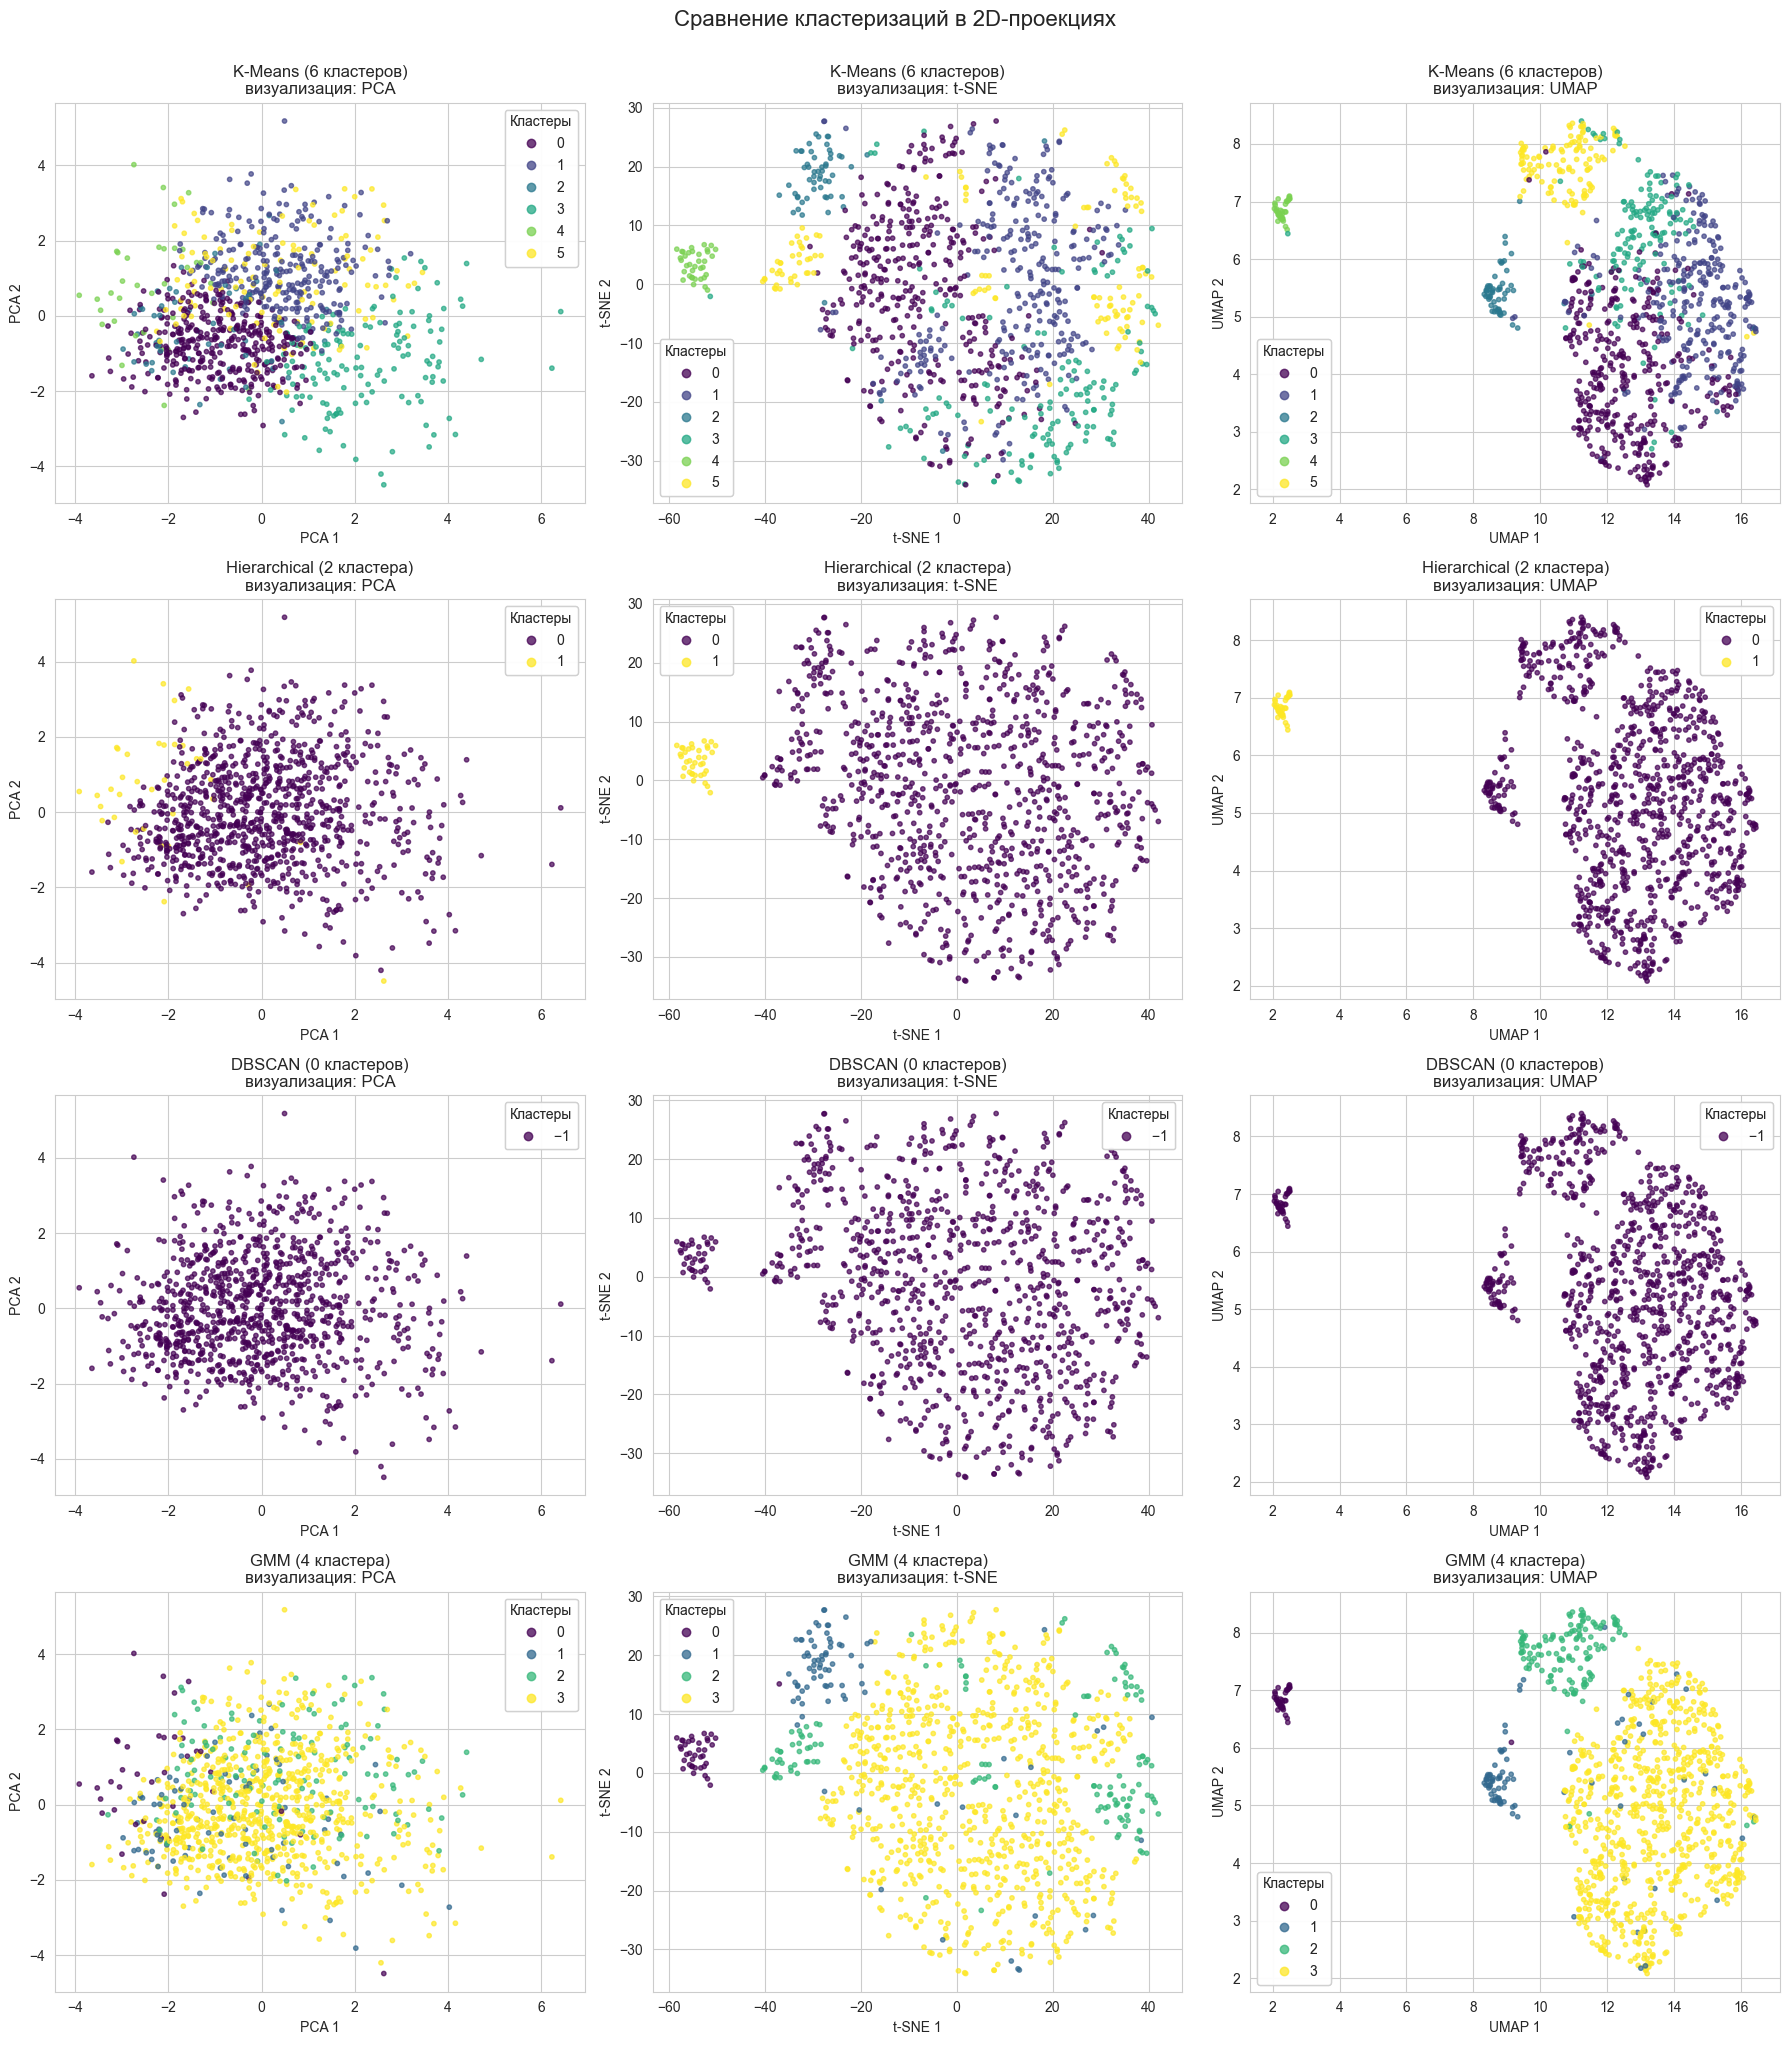

In [51]:
# Визуализация: строки - методы кластеризации, столбцы - методы сжатия
fig, axes = plt.subplots(len(cluster_models), len(reduction_methods), 
                         figsize=(6 * len(reduction_methods), 5 * len(cluster_models)))
# Если только одна строка/столбец, axes нужно сделать двумерным
if len(cluster_models) == 1:
    axes = axes.reshape(1, -1)
if len(reduction_methods) == 1:
    axes = axes.reshape(-1, 1)

for i, (model_name, labels) in enumerate(cluster_models):
    for j, (red_name, X_2d) in enumerate(reductions_2d.items()):
        ax = axes[i, j]
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=10, alpha=0.7)
        if n_clusters ==1:
            c_word = 'кластер'
        elif n_clusters in [2,3,4]:
            c_word = 'кластера'
        elif n_clusters in [0,5,6,7,8,9,10,11,12]:
            c_word = 'кластеров'
        ax.set_title(f'{model_name} ({n_clusters} {c_word})\nвизуализация: {red_name}')
        ax.set_xlabel(f'{red_name} 1')
        ax.set_ylabel(f'{red_name} 2')
        # Добавляем легенду, если кластеров не слишком много
        if n_clusters <= 10:
            legend1 = ax.legend(*scatter.legend_elements(), title="Кластеры")
            ax.add_artist(legend1)
plt.tight_layout()
plt.suptitle('Сравнение кластеризаций в 2D-проекциях', fontsize=16, y=1.02)
plt.show()

**Вывод по визуализации:**
- **PCA**: Показывает направления максимальной дисперсии. K-Means и Hierarchical показывают неплохую разделимость, DBSCAN выделяет ядро и шум.
- **t-SNE**: Лучше показывает локальную структуру, кластеры становятся более компактными, что подтверждает хорошую работу алгоритмов. DBSCAN на t-SNE может выглядеть фрагментированно, так как DBSCAN сам по себе выделяет шум, а t-SNE стягивает плотные области.
- **UMAP**: Часто дает наилучший баланс между глобальной и локальной структурой, показывая четкие и разделимые группы.

# Интерпертация результатов

## 3.1. Таблица средних значений признаков по кластерам

In [68]:
logger.info("Интерпретация кластеров: поиск знаковых и необычных различий между кластерами...")

# Выбираем модель для детальной интерпретации
interpret_model = 'GMM_Cluster'
# =============================================================================
# Шаг 1: Расчёт средних значений и их статистической значимости
# =============================================================================
# Получаем уникальные кластеры (в GMM их ровно optimal_n_gmm, без шума)
unique_clusters = sorted(df_clustered[interpret_model].unique())
# Группируем по кластерам и считаем среднее
cluster_means = df_clustered.groupby(interpret_model).mean()
# Точки, в которых модель уверена слабо, вносят меньший вклад в портрет кластера
feature_columns = [col for col in df_clustered.columns 
                   if col not in [interpret_model, 'GMM_Confidence', 
                                  'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']]

cluster_means_weighted = pd.DataFrame(index=unique_clusters, columns=feature_columns)

for cluster_id in unique_clusters:
    mask = df_clustered[interpret_model] == cluster_id
    cluster_data = df_clustered.loc[mask, feature_columns]
    confidences = df_clustered.loc[mask, 'GMM_Confidence']
    
    # Взвешенное среднее: каждая точка учитывается пропорционально уверенности
    weighted_mean = (cluster_data.multiply(confidences, axis=0).sum() / confidences.sum())
    cluster_means_weighted.loc[cluster_id] = weighted_mean

cluster_means_weighted = cluster_means_weighted.astype(float)
# Выбираем, какой вариант использовать (рекомендую взвешенный для GMM)
use_weighted = True
if use_weighted:
    cluster_means = cluster_means_weighted
    logger.info("Используются ВЗВЕШЕННЫЕ средние (с учётом уверенности GMM)")
else:
    # Оставляем только feature_columns в обычных средних
    cluster_means = cluster_means[feature_columns]
    logger.info("Используются обычные средние")

# Убираем GMM_Confidence из анализа, если она там есть
if 'GMM_Confidence' in cluster_means.columns:
    cluster_means = cluster_means.drop(columns=['GMM_Confidence'])
# Вычисляем три метрики для отбора "интересных" признаков:
# 1. Межкластерная дисперсия (насколько сильно различаются средние)
# 2. Z-score каждого кластера относительно общего среднего (насколько кластер "аномален")
# 3. Коэффициент вариации между кластерами (относительный разброс)

n_clusters = cluster_means.shape[0]
global_mean = df_clustered.drop(columns=[col for col in df_clustered.columns 
                                         if col.endswith('_Cluster') or col == 'GMM_Confidence']).mean()
global_std = df_clustered.drop(columns=[col for col in df_clustered.columns 
                                        if col.endswith('_Cluster') or col == 'GMM_Confidence']).std()

n_clusters = cluster_means.shape[0]

# Глобальные статистики (используем те же feature_columns)
data_for_global = df_clustered[feature_columns]
global_mean = data_for_global.mean()
global_std = data_for_global.std().replace(0, 1e-10)

# 1. Дисперсия средних между кластерами
between_cluster_variance = cluster_means.var(ddof=1)

# 2. Размах средних
range_of_means = cluster_means.max() - cluster_means.min()

# 3. Нормированный размах
normalized_range = range_of_means / global_std

# 4. Z-score и аномальные кластеры
z_scores = (cluster_means - global_mean) / global_std
extreme_clusters_count = (z_scores.abs() > 1.0).sum()

2026-05-07 13:41:38,992 - INFO - Интерпретация кластеров: поиск знаковых и необычных различий между кластерами...
2026-05-07 13:41:39,001 - INFO - Используются ВЗВЕШЕННЫЕ средние (с учётом уверенности GMM)


In [69]:
cluster_confidence = df_clustered.groupby(interpret_model)['GMM_Confidence'].agg(['mean', 'std', 'min'])
cluster_confidence.columns = ['Средняя_уверенность', 'Std_уверенности', 'Мин_уверенность']

# Для каждого признака: корреляция между значением признака и уверенностью в кластере
# Если корреляция высокая — признак важен для определения кластера
feature_confidence_corr = pd.Series(index=feature_columns, dtype=float)
for feat in feature_columns:
    try:
        corr = df_clustered.groupby(interpret_model).apply(
            lambda g: g[feat].corr(g['GMM_Confidence'])
        ).abs().mean()
        feature_confidence_corr[feat] = corr if not np.isnan(corr) else 0
    except:
        feature_confidence_corr[feat] = 0

In [70]:
# Создаём сводную таблицу метрик
feature_interest_df = pd.DataFrame({
    'Дисперсия_межкластерная': between_cluster_variance,
    'Размах_средних': range_of_means,
    'Нормированный_размах': normalized_range,
    'Кластеров_с_аномалией': extreme_clusters_count,
    'Глобальное_среднее': global_mean,
    'Глобальное_std': global_std,
    'Корреляция_с_уверенностью': feature_confidence_corr  # ⬅ НОВОЕ
})

In [75]:
metrics_to_combine = [
    'Дисперсия_межкластерная', 
    'Нормированный_размах', 
    'Кластеров_с_аномалией',
    'Корреляция_с_уверенностью'  
]

In [76]:
# Нормализуем метрики в [0, 1] для комбинирования
from sklearn.preprocessing import MinMaxScaler
scaler_interest = MinMaxScaler()

# Заменяем inf/NaN на 0 перед масштабированием
for col in metrics_to_combine:
    feature_interest_df[col] = feature_interest_df[col].replace([np.inf, -np.inf], np.nan).fillna(0)

scaled_metrics = scaler_interest.fit_transform(feature_interest_df[metrics_to_combine])

# Обновлённые веса: корреляция с уверенностью получает вес
feature_interest_df['Скор_интересности'] = (
    0.25 * scaled_metrics[:, 0] +   # дисперсия
    0.25 * scaled_metrics[:, 1] +   # нормированный размах
    0.30 * scaled_metrics[:, 2] +   # аномальные кластеры (самое важное)
    0.20 * scaled_metrics[:, 3]     # корреляция с уверенностью ⬅ НОВОЕ
)

feature_interest_df = feature_interest_df.sort_values('Скор_интересности', ascending=False)

In [77]:
# Используем "метод локтя" на скорах интереса для отделения значимых признаков от шума
scores = feature_interest_df['Скор_интересности'].values
# Находим точку максимального перепада (elbow)
if len(scores) > 3:
    # Разности между соседними скорами
    diffs = np.diff(scores)
    # Вторые разности для нахождения перегиба
    second_diffs = np.diff(diffs)
    if len(second_diffs) > 0:
        elbow_idx = np.argmax(np.abs(second_diffs)) + 1
    else:
        elbow_idx = len(scores) // 2
    threshold = scores[elbow_idx] if elbow_idx < len(scores) else scores[-1]
else:
    threshold = np.median(scores)

In [78]:
# Получаем уникальные кластеры (в GMM их ровно optimal_n_gmm, без шума)
unique_clusters = sorted(df_clustered[interpret_model].unique())

In [79]:
# Альтернативный порог: верхние 40% признаков
top_k = max(5, int(len(feature_interest_df) * 0.4))
threshold_alt = feature_interest_df['Скор_интересности'].iloc[top_k]
threshold = max(threshold, 0.15)  # минимальный порог, чтобы не показывать всё подряд

# Разделяем на "значимые" и "фоновые"
significant_features = feature_interest_df[feature_interest_df['Скор_интересности'] >= threshold]
background_features = feature_interest_df[feature_interest_df['Скор_интересности'] < threshold]

logger.info(f"Отобрано {len(significant_features)} значимых признаков из {len(feature_interest_df)}")
logger.info(f"Порог интереса: {threshold:.3f}")
logger.info(f"Скрыто фоновых признаков: {len(background_features)}")


2026-05-07 13:50:33,171 - INFO - Отобрано 4 значимых признаков из 20
2026-05-07 13:50:33,172 - INFO - Порог интереса: 0.150
2026-05-07 13:50:33,173 - INFO - Скрыто фоновых признаков: 16


In [80]:
# Раскрашиваем: по строкам — каждый кластер подсвечиваем относительно глобального среднего
# Создаём кастомную раскраску: зелёный = выше среднего, красный = ниже среднего
def color_cluster_cells(df):
    """Подсветка ячеек: зелёный если значение выше глобального среднего, красный если ниже"""
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in df.columns:
        global_avg = global_mean.get(col, df[col].mean())
        for idx in df.index:
            if df.loc[idx, col] > global_avg * 1.05:  # на 5% выше среднего
                styles.loc[idx, col] = 'background-color: #c6efce; color: #006100'  # зелёный
            elif df.loc[idx, col] < global_avg * 0.95:  # на 5% ниже среднего
                styles.loc[idx, col] = 'background-color: #ffc7ce; color: #9c0006'  # красный
    return styles


🎯 ХАРАКТЕРИСТИКИ КЛАСТЕРОВ GMM (GMM_Cluster)


,Размер,Доля,Средняя_уверенность,Разброс_уверенности,Минимальная_уверенность,Точек_в_ядре_(>0.8),Доля_ядра
0,38,3.8%,1.000000,0.000000,1.000000,38,100.0%
1,82,8.2%,1.000000,0.000000,1.000000,82,100.0%
2,131,13.1%,1.000000,0.000000,1.000000,131,100.0%
3,749,74.9%,1.000000,0.000000,1.000000,749,100.0%


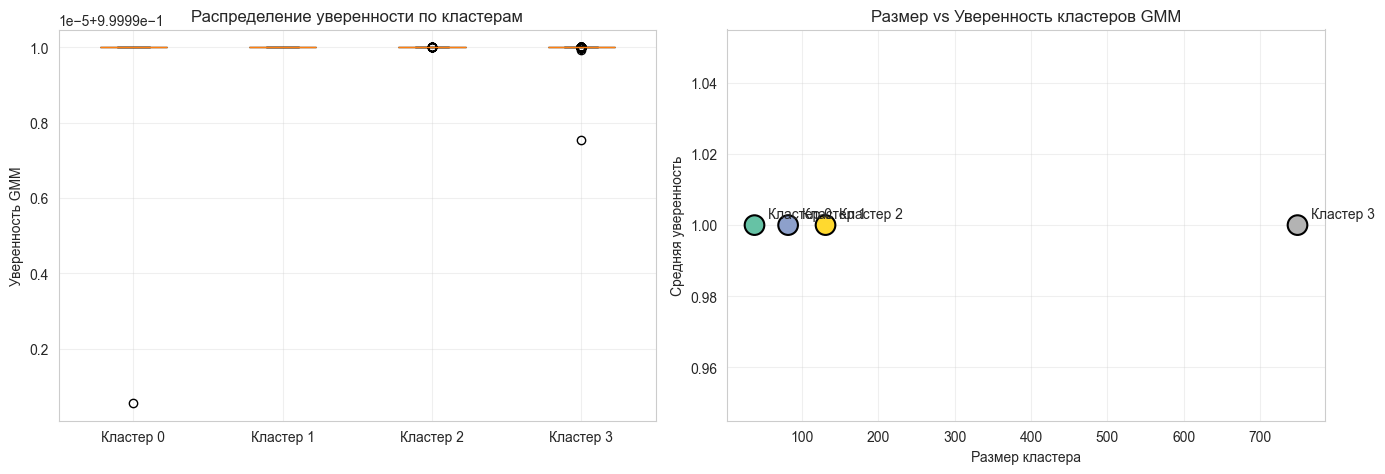

In [81]:
print("\n" + "="*70)
print(f"🎯 ХАРАКТЕРИСТИКИ КЛАСТЕРОВ GMM ({interpret_model})")
print("="*70)

# Таблица с информацией о кластерах
cluster_info = pd.DataFrame(index=unique_clusters)
cluster_info['Размер'] = df_clustered[interpret_model].value_counts().sort_index()
cluster_info['Доля'] = (cluster_info['Размер'] / len(df_clustered) * 100).round(1).astype(str) + '%'
cluster_info['Средняя_уверенность'] = cluster_confidence['Средняя_уверенность'].round(3)
cluster_info['Разброс_уверенности'] = cluster_confidence['Std_уверенности'].round(3)
cluster_info['Минимальная_уверенность'] = cluster_confidence['Мин_уверенность'].round(3)

# Определяем «ядро» кластера: точки с уверенностью > 0.8
cluster_info['Точек_в_ядре_(>0.8)'] = df_clustered.groupby(interpret_model)['GMM_Confidence'].apply(
    lambda x: (x > 0.8).sum()
)
cluster_info['Доля_ядра'] = (cluster_info['Точек_в_ядре_(>0.8)'] / cluster_info['Размер'] * 100).round(1).astype(str) + '%'

display(cluster_info.style.background_gradient(cmap='Blues', subset=['Средняя_уверенность', 'Точек_в_ядре_(>0.8)']))

# Визуализация уверенности по кластерам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Boxplot уверенности по кластерам
conf_data = [df_clustered[df_clustered[interpret_model] == c]['GMM_Confidence'] 
             for c in unique_clusters]
bp = axes[0].boxplot(conf_data, labels=[f'Кластер {c}' for c in unique_clusters], 
                     patch_artist=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_clusters)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Уверенность GMM')
axes[0].set_title('Распределение уверенности по кластерам')
axes[0].grid(True, alpha=0.3)

# График 2: Размер кластера vs уверенность
sizes = cluster_info['Размер'].values
confidences = cluster_info['Средняя_уверенность'].values
scatter = axes[1].scatter(sizes, confidences, c=range(len(unique_clusters)), 
                          cmap='Set2', s=200, edgecolors='black', linewidth=1.5)
for i, c in enumerate(unique_clusters):
    axes[1].annotate(f'Кластер {c}', (sizes[i], confidences[i]),
                     xytext=(10, 5), textcoords='offset points', fontsize=10)
axes[1].set_xlabel('Размер кластера')
axes[1].set_ylabel('Средняя уверенность')
axes[1].set_title('Размер vs Уверенность кластеров GMM')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [82]:
print("\n" + "="*70)
print(f"ЗНАЧИМЫЕ РАЗЛИЧИЯ МЕЖДУ КЛАСТЕРАМИ ({interpret_model})")
print("Показаны только признаки, по которым кластеры действительно различаются.")
print(f"Фоновые признаки ({len(background_features)} шт.) скрыты как неинформативные.")
print("="*70)

# Таблица средних значений ТОЛЬКО для значимых признаков
significant_features_list = significant_features.index.tolist()
cluster_means_significant = cluster_means[significant_features_list].round(2)

# Сортируем столбцы по скору интересности
cluster_means_significant = cluster_means_significant[significant_features_list]
# Выводим основную таблицу
print(f"\n📊 Средние значения ЗНАЧИМЫХ признаков по кластерам:")
display(cluster_means_significant.style
        .apply(color_cluster_cells, axis=None)
        .format("{:.2f}")
        .set_caption(f"Зелёный = выше среднего по всем данным, Красный = ниже среднего"))


ЗНАЧИМЫЕ РАЗЛИЧИЯ МЕЖДУ КЛАСТЕРАМИ (GMM_Cluster)
Показаны только признаки, по которым кластеры действительно различаются.
Фоновые признаки (16 шт.) скрыты как неинформативные.

📊 Средние значения ЗНАЧИМЫХ признаков по кластерам:


,foreign_worker,Other_debtors_guarantors,Number_of_people_being_liable_to_provide_maintenance_for,Credit_amount
0,0.97,0.47,1.32,2689.63
1,0.00,1.55,1.15,3385.34
2,0.00,0.00,2.00,3467.29
3,0.00,0.00,1.00,3253.99


In [83]:
print("\n" + "="*70)
print("🔍 ДЕТАЛЬНЫЙ РАЗБОР: КАКИЕ КЛАСТЕРЫ И ПО КАКИМ ПРИЗНАКАМ ВЫДЕЛЯЮТСЯ")
print("="*70)

for feature in significant_features_list[:12]:  # Топ-12, чтобы не перегружать вывод
    feature_data = cluster_means[feature]
    global_avg = global_mean[feature]
    global_std_val = global_std[feature]
    
    print(f"\n{'─'*60}")
    print(f"📌 Признак: {feature}")
    print(f"   Глобальное среднее: {global_avg:.2f} (±{global_std_val:.2f})")
    print(f"   Размах между кластерами: {feature_data.min():.2f} – {feature_data.max():.2f}")
    
    # Находим кластеры, которые сильнее всего отклоняются
    z_scores_feature = z_scores[feature]
    
    extreme_clusters = []
    for cluster_id in z_scores_feature.index:
        z = z_scores_feature[cluster_id]
        mean_val = feature_data[cluster_id]
        if abs(z) > 1.0:
            direction = "🔼 ВЫШЕ" if z > 0 else "🔽 НИЖЕ"
            extreme_clusters.append((cluster_id, direction, mean_val, z))
    
    if extreme_clusters:
        print(f"   Кластеры с аномальными значениями (|z| > 1.0):")
        for cluster_id, direction, mean_val, z in extreme_clusters:
            print(f"      Кластер {cluster_id}: {direction} среднего ({mean_val:.2f}, z={z:+.2f})")
    else:
        # Даже если нет сильных аномалий, показываем топ-2 кластеров с наибольшим отклонением
        top_deviations = z_scores_feature.abs().nlargest(2)
        print(f"   Наибольшие отклонения (хотя и в пределах нормы):")
        for cluster_id in top_deviations.index:
            z_val = z_scores_feature[cluster_id]
            direction = "выше" if z_val > 0 else "ниже"
            print(f"      Кластер {cluster_id}: {direction} на {abs(z_val):.2f}σ ({feature_data[cluster_id]:.2f})")


🔍 ДЕТАЛЬНЫЙ РАЗБОР: КАКИЕ КЛАСТЕРЫ И ПО КАКИМ ПРИЗНАКАМ ВЫДЕЛЯЮТСЯ

────────────────────────────────────────────────────────────
📌 Признак: foreign_worker
   Глобальное среднее: 0.04 (±0.19)
   Размах между кластерами: 0.00 – 0.97
   Кластеры с аномальными значениями (|z| > 1.0):
      Кластер 0: 🔼 ВЫШЕ среднего (0.97, z=+4.96)

────────────────────────────────────────────────────────────
📌 Признак: Other_debtors_guarantors
   Глобальное среднее: 0.14 (±0.48)
   Размах между кластерами: 0.00 – 1.55
   Кластеры с аномальными значениями (|z| > 1.0):
      Кластер 1: 🔼 ВЫШЕ среднего (1.55, z=+2.94)

────────────────────────────────────────────────────────────
📌 Признак: Number_of_people_being_liable_to_provide_maintenance_for
   Глобальное среднее: 1.16 (±0.36)
   Размах между кластерами: 1.00 – 2.00
   Кластеры с аномальными значениями (|z| > 1.0):
      Кластер 2: 🔼 ВЫШЕ среднего (2.00, z=+2.33)

────────────────────────────────────────────────────────────
📌 Признак: Credit_amount
   Г

In [84]:
print("\n" + "="*70)
print("🙈 СКРЫТЫЕ ПРИЗНАКИ (не показали значимых различий между кластерами)")
print("="*70)

# Группируем скрытые признаки по причине
hidden_features = background_features.index.tolist()
print(f"Скрыто признаков: {len(hidden_features)} из {len(feature_interest_df)}")
print(f"Порог скрытия: Скор интереса < {threshold:.3f}")
print(f"\nСписок скрытых признаков:")
for i, feat in enumerate(hidden_features, 1):
    score = feature_interest_df.loc[feat, 'Скор_интересности']
    range_val = feature_interest_df.loc[feat, 'Размах_средних']
    print(f"   {i:2d}. {feat:<45s} (Скор: {score:.3f}, Размах: {range_val:.3f})")


🙈 СКРЫТЫЕ ПРИЗНАКИ (не показали значимых различий между кластерами)
Скрыто признаков: 16 из 20
Порог скрытия: Скор интереса < 0.150

Список скрытых признаков:
    1. Duration_in_month                             (Скор: 0.050, Размах: 8.423)
    2. Property                                      (Скор: 0.047, Размах: 0.895)
    3. Telephone                                     (Скор: 0.046, Размах: 0.277)
    4. Housing                                       (Скор: 0.046, Размах: 0.378)
    5. Savings_account_bonds                         (Скор: 0.039, Размах: 0.822)
    6. Job                                           (Скор: 0.036, Размах: 0.364)
    7. Purpose                                       (Скор: 0.028, Размах: 1.878)
    8. Present_employment_since                      (Скор: 0.026, Размах: 0.572)
    9. Other_installment_plans                       (Скор: 0.025, Размах: 0.210)
   10. Status_of_existing_checking_account           (Скор: 0.025, Размах: 0.528)
   11. Present_resid

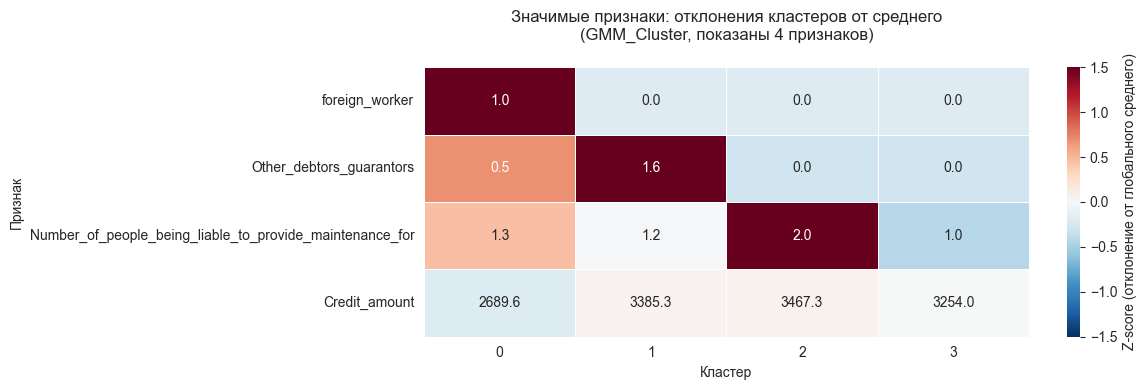

In [85]:
fig, ax = plt.subplots(figsize=(12, max(4, len(significant_features_list) * 0.4)))

# Центрируем данные относительно глобального среднего для тепловой карты
cluster_means_centered = cluster_means_significant - global_mean[significant_features_list]
# Делим на глобальное std чтобы получить z-score
cluster_means_z = cluster_means_centered / global_std[significant_features_list].replace(0, 1)

# Тепловая карта z-score
sns.heatmap(cluster_means_z.T, 
            annot=cluster_means_significant.T.round(1).values,  # реальные значения
            fmt='.1f',
            cmap='RdBu_r',       # красно-синяя: красный=выше, синий=ниже
            center=0,
            vmin=-1.5, vmax=1.5,
            cbar_kws={'label': 'Z-score (отклонение от глобального среднего)'},
            ax=ax,
            linewidths=0.5,
            linecolor='white')

ax.set_title(f'Значимые признаки: отклонения кластеров от среднего\n'
             f'({interpret_model}, показаны {len(significant_features_list)} признаков)',
             fontsize=12, pad=20)
ax.set_xlabel('Кластер')
ax.set_ylabel('Признак')

# Поворачиваем подписи признаков для читаемости
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 3.2. BOXPLOT-ы ДЛЯ ВИЗУАЛЬНОЙ ИНТЕРПРЕТАЦИИ РАЗЛИЧИЙ КЛАСТЕРОВ (GMM)

In [88]:
logger.info("Построение boxplot'ов для анализа различий кластеров GMM...")

# Определяем признаки для визуализации (все, кроме мета-колонок)
feature_cols = [col for col in df_clustered.columns 
                if col not in [interpret_model, 'GMM_Confidence', 
                               'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']]

# Если признаков много (>20), используем только значимые (из feature_interest_df)
# Порог значимости можно взять из предыдущего анализа (threshold)
if len(feature_cols) > 20:
    # Берём все значимые признаки, но не более 20
    significant_list = significant_features_list[:20]
    feature_cols = [f for f in feature_cols if f in significant_list]
    logger.info(f"Для boxplot'ов отобрано {len(feature_cols)} значимых признаков (из economic).")
else:
    logger.info(f"Количество признаков ({len(feature_cols)}) ≤ 20, будут показаны все.")

# Сортируем признаки по скору интересности (из feature_interest_df, если есть)
if 'feature_interest_df' in locals() and not feature_interest_df.empty:
    # Убедимся, что все feature_cols есть в индексе
    sorted_features = feature_interest_df.loc[feature_cols].sort_values('Скор_интересности', ascending=False).index.tolist()
else:
    sorted_features = feature_cols  # fallback: алфавитный порядок

2026-05-07 13:54:09,309 - INFO - Построение boxplot'ов для анализа различий кластеров GMM...
2026-05-07 13:54:09,310 - INFO - Количество признаков (20) ≤ 20, будут показаны все.


Построение boxplot'ов:   0%|          | 0/20 [00:00<?, ?it/s]2026-05-07 13:54:25,817 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 13:54:25,823 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 13:54:25,852 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 13:54:25,856 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 13:54:25,883 - INFO - Using categori

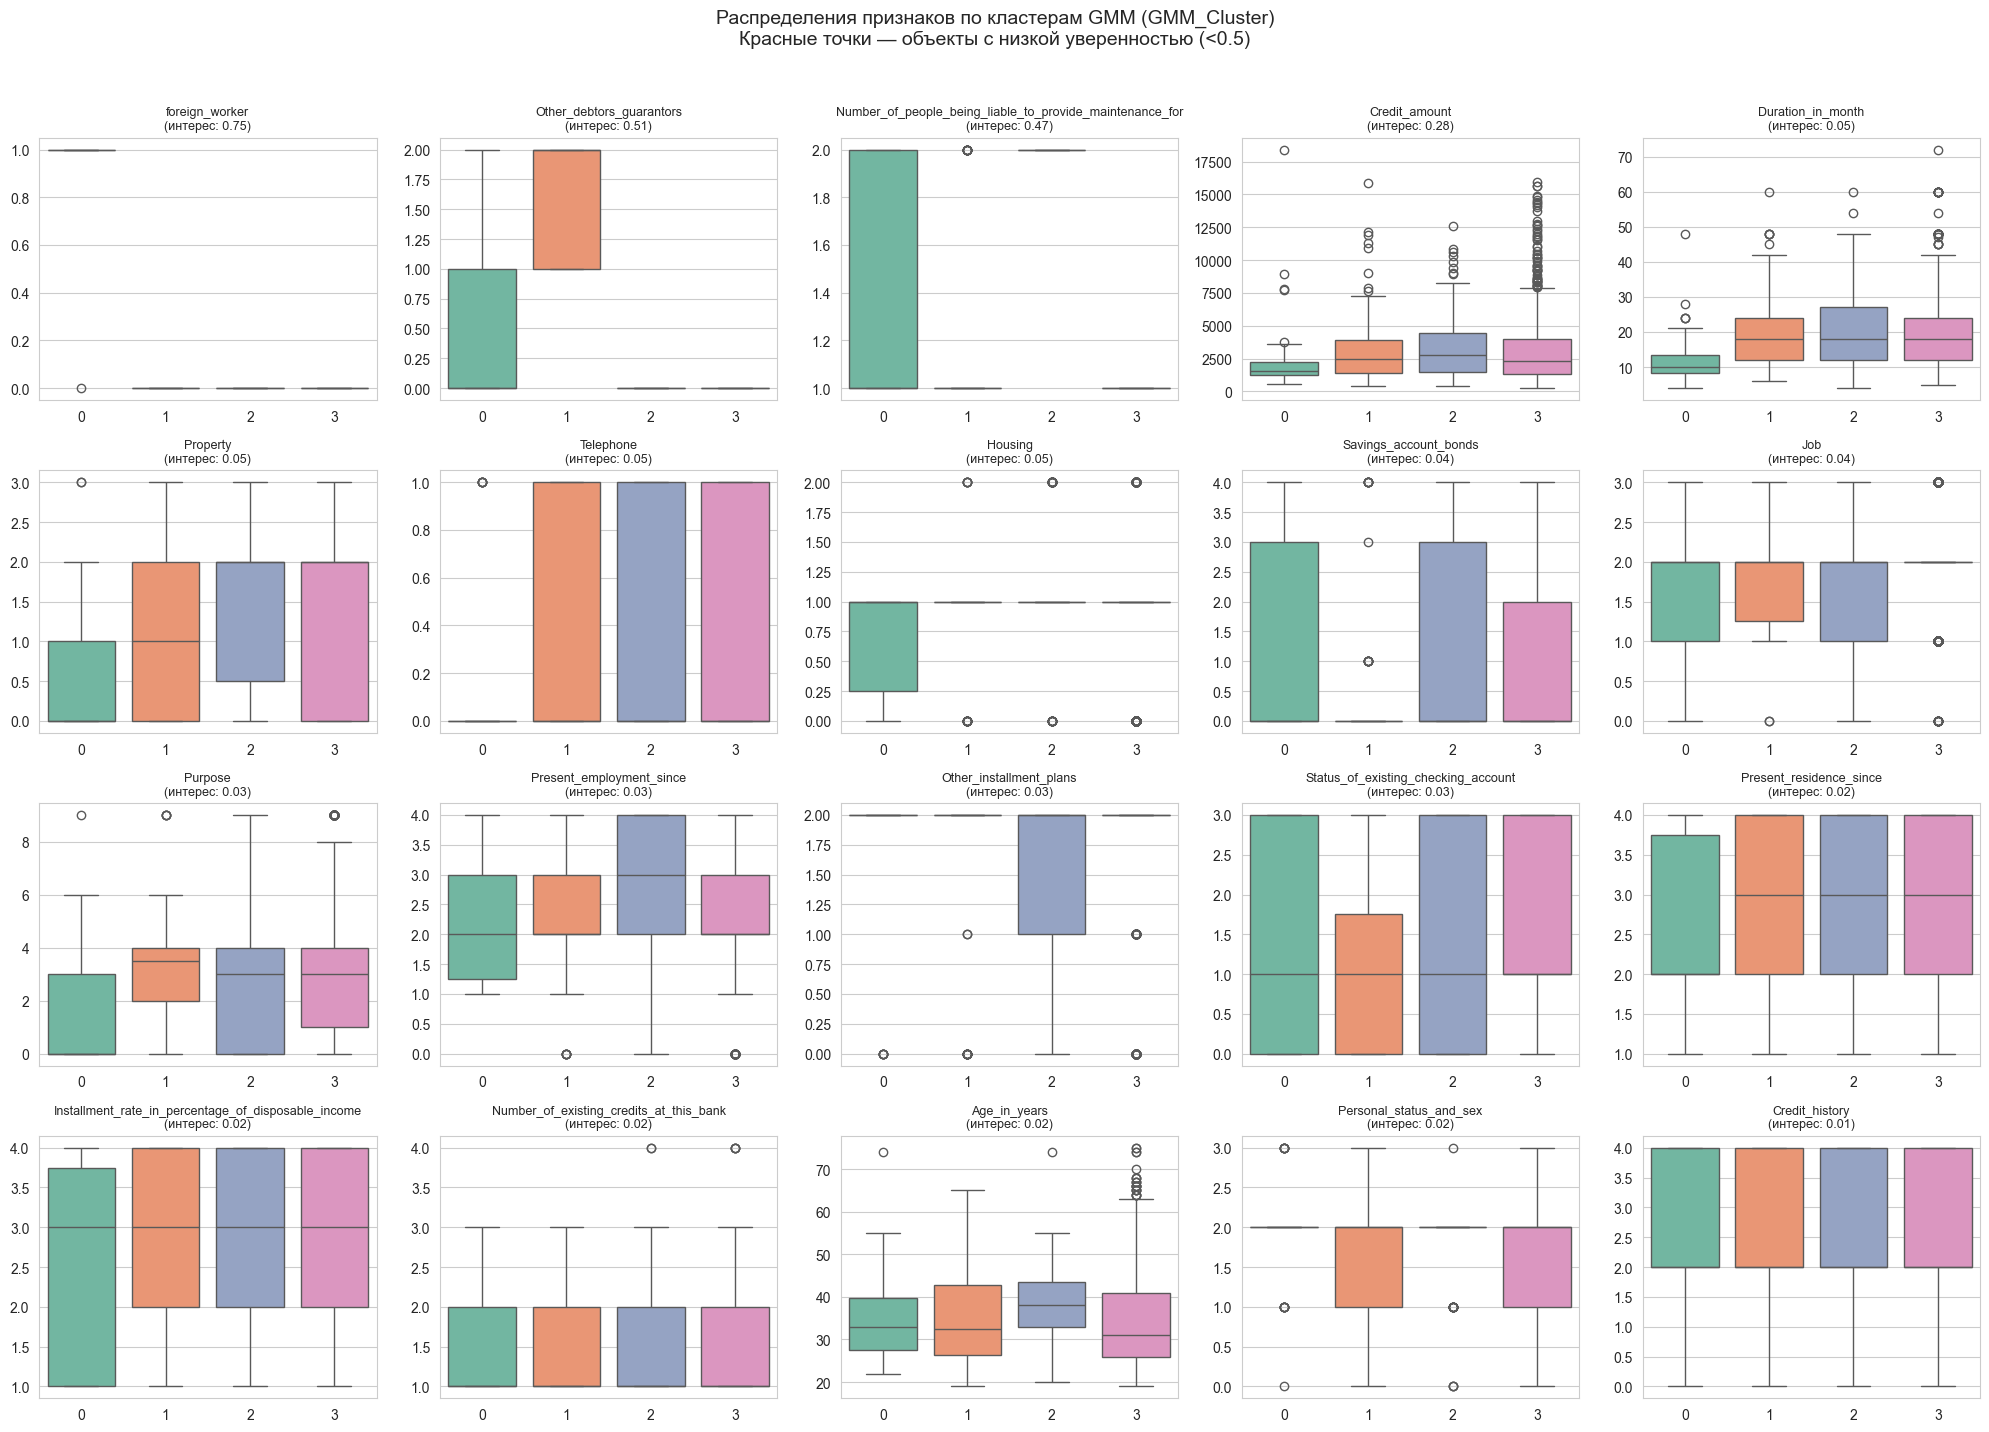

In [89]:
# Строим сетку boxplot'ов
n_features = len(sorted_features)
n_cols = 5
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
axes = axes.flatten() if n_features > 1 else [axes]

# Палитра для кластеров (уникальные цвета)
unique_clusters = sorted(df_clustered[interpret_model].unique())
n_clusters = len(unique_clusters)
palette = sns.color_palette("Set2", n_clusters)
cluster_colors = {c: palette[i] for i, c in enumerate(unique_clusters)}

for i, feature in enumerate(tqdm(sorted_features, desc="Построение boxplot'ов")):
    ax = axes[i]
    # Строим boxplot с группировкой по кластерам
    # Используем оригинальные данные (не масштабированные, не взвешенные) для реальных значений
    sns.boxplot(x=interpret_model, y=feature, data=df_clustered, 
                order=unique_clusters, ax=ax, palette=palette)
    
    # Добавляем наложение stripplot для точек с низкой уверенностью (если GMM)
    # Покажем точки с уверенностью < 0.5 как полупрозрачные
    low_conf = df_clustered[df_clustered['GMM_Confidence'] < 0.5]
    if not low_conf.empty:
        sns.stripplot(x=interpret_model, y=feature, data=low_conf, 
                      order=unique_clusters, ax=ax, color='red', alpha=0.15, 
                      size=4, jitter=True)
    
    # Добавим скор интересности в заголовок, если есть
    interest_score = feature_interest_df.loc[feature, 'Скор_интересности'] if feature in feature_interest_df.index else 0
    ax.set_title(f'{feature}\n(интерес: {interest_score:.2f})', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # Убираем легенду, если она дублируется
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Скрываем лишние оси
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Распределения признаков по кластерам GMM ({interpret_model})\n'
             f'Красные точки — объекты с низкой уверенностью (<0.5)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

📌 ВЫВОДЫ ВСЕМУ КЛАСТЕРНОМУ АНАЛИЗУ
  
Алгоритм Gaussian Mixture Model (GMM) выделил четыре статистически значимых сегмента клиентской базы, демонстрирующих принципиальные различия по социально-демографическим и кредитным характеристикам. Ключевые разделители (признаки с наивысшим «интересом»): статус иностранного работника, наличие поручителей, количество иждивенцев и размер кредитной сделки. Каждый кластер требует индивидуальной стратегии риск-менеджмента и маркетинга.  
  
1. *Профили сегментов*  
    Кластер 0: «Трудовые мигранты-арендаторы» (высокорисковый массовый сегмент)  
    Маркер: foreign_worker = 0.97 (против 0.04 в среднем по портфелю)  
    Кредитный профиль: минимальные суммы (2 690 у.е., −0.21σ), короткие сроки (медиана ≈ 12 мес.), отсутствие собственности (низкие значения Property/Housing), преимущественно арендное жилье.  
    Риски: высокая мобильность (риск «молчаливого» оттока из страны), отсутствие залогового обеспечения, потенциальная нестабильность трудового статуса.  
    Бизнес-ценность: низкий чек, высокая частота обращений (оборот), низкая кросс-продажная емкость.  
    
    Кластер 1: «Социально обеспеченные заемщики» (средний риск)  
    Маркер: Other_debtors_guarantors = 1.55 (z=+2.94) — наличие поручителя или созаемщика  
    Кредитный профиль: средние суммы (≈ 3 000 у.е.), стандартные сроки, нейтральная кредитная история.  
    Особенность: кредитная сделка поддержана третьими лицами (вероятно, родителями для молодых заемщиков или супругами).  
    Риски: зависимость от платежеспособности поручителя; при дефолте — сложности с взысканием из-за множественных участников.  
    Возможности: низкий удельный вес дефолта благодаря социальному контролю со стороны поручителей.  
    
    Кластер 2: «Семьи с иждивенцами» (прибыльный сегмент роста)  
    Маркер: Number_of_people_liable = 2.0 (z=+2.33) — наличие двух иждивенцев (типичная модель «ребенок + супруг»)  
    Кредитный профиль: максимальные суммы (3 467 у.е., +0.07σ), стабильный трудовой стаж (высокие значения Present_employment_since), целевое использование (вероятно, бытовая техника, образование, ремонт).  
    Риски: высокая долговая нагрузка на душу дохода; чувствительность к экономическим кризисам (потеря работы главного кормильца).
    Возможности: высокий потенциал кросс-продаж (ипотека в будущем, страхование жизни, накопительные продукты для детей).  
    
    Кластер 3: «Стабильные собственники» (низкий риск, премиум)  
    Маркер: высокий возраст (медиана 40+ лет), длительные сроки кредитования (Duration), наличие недвижимости (высокие Property/Housing)  
    Кредитный профиль: широкий разброс сумм (включая высокие выбросы до 18 000 у.е.), длительные сроки (> 36 мес.), низкая доля иждивенцев (1 человек).  
    Риски: минимальны; высокая лояльность и «инерция» клиента.  
    Особенность: наличие «красных точек» (низкая уверенность GMM) в этом сегменте указывает на граничные случаи между «собственниками» и «семьями», требующие ручной верификации при скоринге.  

3. *Стратегические рекомендации*
>
|Сегмент	|Управление рисками	|Маркетинг & Retention|
|-----------|-------------------|---------------------|
|Кластер 0	|Ужесточить требования к трудовому договору (срок действия > срока кредита); введение микро-залогов (техника); мониторинг миграционного статуса	|Массовые предложения с коротким сроком одобрения; SMS-информирование; продукты для переводов за рубеж|
|Кластер 1	|Оценка платежеспособности поручителя наравне с основным заемщиком; юридическая чистота договоров поручительства	|Программы «рефинансирование с пониженной ставкой при наличии поручителя»; семейные пакеты услуг|
|Кластер 2	|Жесткий контроль PTI (debt-to-income); обязательное страхование жизни и трудоспособности; лимитирование суммы в зависимости от количества иждивенцев	|Кросс-селлинг ипотеки, накопительных счетов для детей; сезонные предложения (к школе, к отпуску)|
|Кластер 3	|Упрощенная схема одобрения (express-скоринг); преференциальные ставки за лояльность	|VIP-обслуживание; премиальные карты; консьерж-сервис; продукты для инвестиций и управления капиталом|


**Итог**: Портфель диверсифицирован по риск-профилям, но требует сегментированного ценообразования. Кластер 0 требует микро-кредитной стратегии с усиленным мониторингом, Кластер 2 — защиты от перекредитованности, а Кластер 3 — удержания через премиальный сервис.